# Машинное обучение, ФКН ВШЭ

## Практическое задание 2. Exploratory Data Analysis и линейная регрессия

### Общая информация
Дата выдачи: 12.10.2024

Мягкий дедлайн: 23:59MSK 27.10.2024

Жесткий дедлайн: 23:59MSK 31.10.2024

### О задании
В этом задании мы попытаемся научиться анализировать данные и выделять из них полезные признаки. Мы также научимся пользоваться `sklearn`, а заодно привыкнем к основным понятиям машинного обучения.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов. Проверяющий имеет право снизить оценку за неэффективную реализацию или неопрятные графики.

**Обратите внимание**, что в каждом разделе домашнего задания есть оцениваниемые задачи и есть вопросы. Вопросы дополняют задачи и направлены на то, чтобы проинтерпретировать или обосновать происходящее. Код без интерпретации не имеет смысла, поэтому отвечать на вопросы обязательно — за отсутствие ответов мы будем снижать баллы за задачи. Если вы ответите на вопросы, но не напишете корректный код к соответствующим оцениваемым задачам, то баллы за такое выставлены не будут.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате homework-practice-02-linregr-Username.ipynb, где Username — ваша фамилия.

Для удобства проверки самостоятельно посчитайте свою максимальную оценку (исходя из набора решенных задач) и укажите ниже.

Оценка: xx.

В этом ноутбуке используется библиотека `folium` для визуализации карт. Она работает в google colab!

In [134]:
!pip install folium

In [527]:
import folium

m = folium.Map(location=(50.97178, 9.79418), zoom_start=15)

m

Если вы всё сделали правильно, то выше должна открыться карта

### 📌 **Памятка по дз2**

Обрабатывать данные можно любым способом (`polars`, `pandas`, `pyspark`, ...), который вам нравится и запускается в ноутбуке, и любой библиотекой для визуализации (`matplotlib`, `seaborn`, `plotly`, ...). Пользуйтесь на здоровье, но!

> Учтите, что `polars` всё ещё молодой и не все библиотеки его поддерживают. `sklearn` во многом уже работает, но на всякий случай не стесняйтесь пользоваться методами `pl.DataFrame.to_pandas()` или `pl.DataFrame.to_numpy()`    

> Впрочем, `pandas` тоже не лишён проблем. `sklearn` принимает `pd.DataFrame` почти везде, проблемы очень редки, но если вдруг возникнет какая-то беда с шейпами, или ещё какой-нибудь казус, а вы уверены, что всё правильно, пользуйтесь `pd.DataFrame.to_numpy()`. Это не всегда решает проблему, но часто помогает понять, что на самом деле не так. При желании можно передавать и `Iterable`, и sparse-матрицы

> Графики должны быть понятные, читаемые и пр. Консультируйтесь с памяткой из дз1 в задании на график

> Для воспроизводимости результатов не забывайте пользоваться `np.random.seed(...)`, при необходимости чистите мусор `gc.collect()`, лучше в каждой ячейке

> Все результаты должны быть получены в ноутбуке. На каждый **Вопрос** долен быть дан **Ответ** (письменно (в Markdown например) или кодом)

In [528]:
import numpy as np
import pandas as pd
import plotly
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

## Часть 0. Подготовка (1 балл)

**Задание 1 (1 балл)**. Мы будем работать с данными из соревнования [New York City Taxi Trip Duration](https://www.kaggle.com/c/nyc-taxi-trip-duration/overview), в котором нужно было предсказать длительность поездки на такси. Скачайте обучающую выборку из этого соревнования и загрузите ее:

In [529]:
data = pd.read_csv('train.csv')
data.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


Обратите внимание на колонки `pickup_datetime` и `dropoff_datetime`. `dropoff_datetime` был добавлена организаторами только в обучающую выборку, то есть использовать эту колонку нельзя, давайте удалим ее. В `pickup_datetime` записаны дата и время начала поездки. Чтобы с ней было удобно работать, давайте преобразуем даты в `datetime`-объекты

In [530]:
data.drop(columns=['dropoff_datetime'], inplace=True)
data['pickup_datetime'] = pd.to_datetime(data['pickup_datetime'])
data.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435


В колонке `trip_duration` записано целевое значение, которое мы хотим предсказывать. Давайте посмотрим на распределение таргета в обучающей выборке. Для этого нарисуйте его гистограмму:

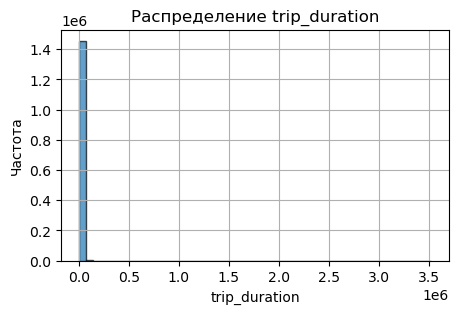

count    1.458644e+06
mean     9.594923e+02
std      5.237432e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64

In [531]:
import pandas as pd
import matplotlib.pyplot as plt

f, ax = plt.subplots(figsize=(5, 3))
plt.grid()
ax.hist(data['trip_duration'], bins=50, edgecolor='black', alpha=0.7)
ax.set_title("Распределение trip_duration")
ax.set_xlabel("trip_duration")
ax.set_ylabel("Частота")
plt.show()
data['trip_duration'].describe()

**Вопрос**: Что можно сказать о целевой переменной по гистограмме её значений?

**Ответ**:Большая часть значений trip_duration находятся около нуля, но максимальное значение trip_duration значительно превышает остальные значения

В соревновании в качестве метрики качества использовалось RMSLE:
$$\text{RMSLE}(X, y, a) = \sqrt{\frac{1}{\ell}\sum_{i=1}^{\ell} \big(\log{(y_i + 1)} - \log{(a(x_i) + 1)}\big)^2}$$

**Вопрос**: Как вы думаете, почему авторы соревнования выбрали именно RMSLE, а не RMSE?

**Ответ**: RMSLE менее чувствителен к выбросам по сравнению с RMSE.

На семинаре мы рассматривали несколько моделей линейной регрессии в `sklearn`, но каждая из них оптимизировала среднеквадратичную ошибку (MSE), а не RMSLE. Давайте проделаем следующий трюк: будем предсказывать не целевую переменную, а ее *логарифм*. Обозначим $\hat{y}_i = \log{(y_i + 1)}$ — модифицированный таргет, а $\hat{a}(x_i)$ — предсказание модели, которая обучалась на $\hat{y}_i$, то есть логарифм таргета. Чтобы предсказать исходное значение, мы можем просто взять экспоненту от нашего предсказания: $a(x_i) = \exp(\hat{a}(x_i)) - 1$.

**Вопрос**: Покажите, что оптимизация RMSLE для модели $a$ эквивалентна оптимизации MSE для модели $\hat{a}$.

**Доказательство**: 

$$\text{RMSLE}(X, y, a) = \sqrt{\frac{1}{\ell}\sum_{i=1}^{\ell} \big(\log{(y_i + 1)} - \log{(a(x_i) + 1)}\big)^2}$$
$$\text{RMSE}(X,\hat{y}, \hat{a}) = \frac{1}{n}\sum_{i=1}^{n} \big(\hat{y}_i - \hat{a}(x_i)\big)^2
= \frac{1}{n}\sum_{i=1}^{n} \big(\log{(y_i + 1)} - \log{(a(x_i) + 1)}\big)^2$$
$$
(\hat{y}_i - \hat{a}(x_i)) \Longrightarrow min
$$
т.е. оптимизируем одинаковые выражения

Итак, мы смогли свести задачу оптимизации RMSLE к задаче оптимизации MSE, которую мы умеем решать! Кроме того, у логарифмирования таргета есть еще одно полезное свойство. Чтобы его увидеть, добавьте к нашей выборке колонку `log_trip_duration` (воспользуйтесь `np.log1p`) и нарисуйте гистограмму модифицированного таргета по обучающей выборке. Удалите колонку со старым таргетом.

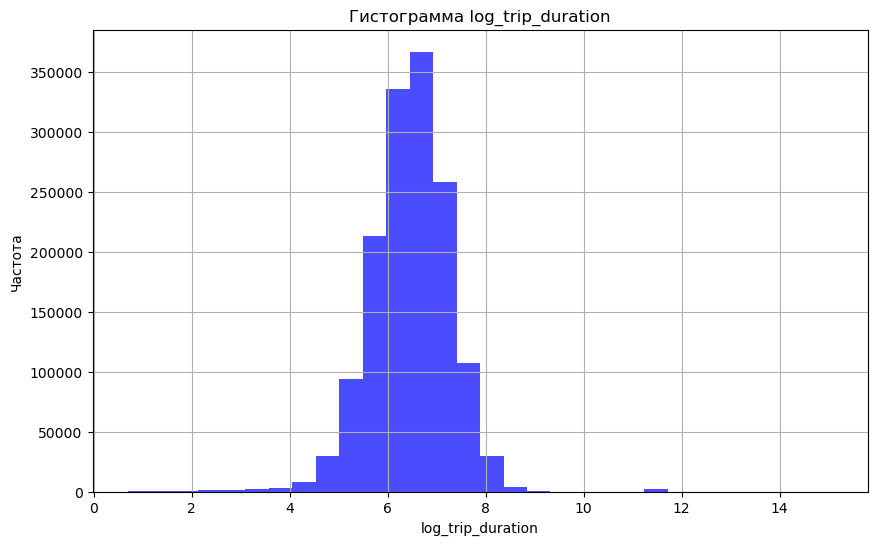

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,log_trip_duration
0,id2875421,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,6.122493
1,id2377394,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,6.498282
2,id3858529,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,7.661527
3,id3504673,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,6.063785
4,id2181028,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,6.077642


In [532]:
data['log_trip_duration'] = np.log1p(data['trip_duration'])

plt.figure(figsize=(10, 6))
plt.grid()
plt.hist(data['log_trip_duration'], bins=30, color='blue', alpha=0.7)
plt.title('Гистограмма log_trip_duration')
plt.xlabel('log_trip_duration')
plt.ylabel('Частота')
plt.show()

data.drop(columns=['trip_duration'], inplace=True)
data.head()

Чтобы иметь некоторую точку отсчета, давайте посчитаем значение метрики при наилучшем константном предсказании:

In [533]:
def rmsle(log1p_y_true, log1p_y_pred):
    return np.sqrt(np.mean((log1p_y_true - log1p_y_pred) ** 2))

rmsle_best_const = rmsle(data['log_trip_duration'], np.mean(data['log_trip_duration']))
print(rmsle_best_const)
assert np.allclose(rmsle_best_const, 0.79575, 1e-4)

0.7957592365411509


## Часть 1. Изучаем `pickup_datetime` (2 балла)

**Задание 2 (0.25 баллов)**. Для начала давайте посмотрим, сколько всего было поездок в каждый из дней. Постройте график зависимости количества поездок от дня в году:

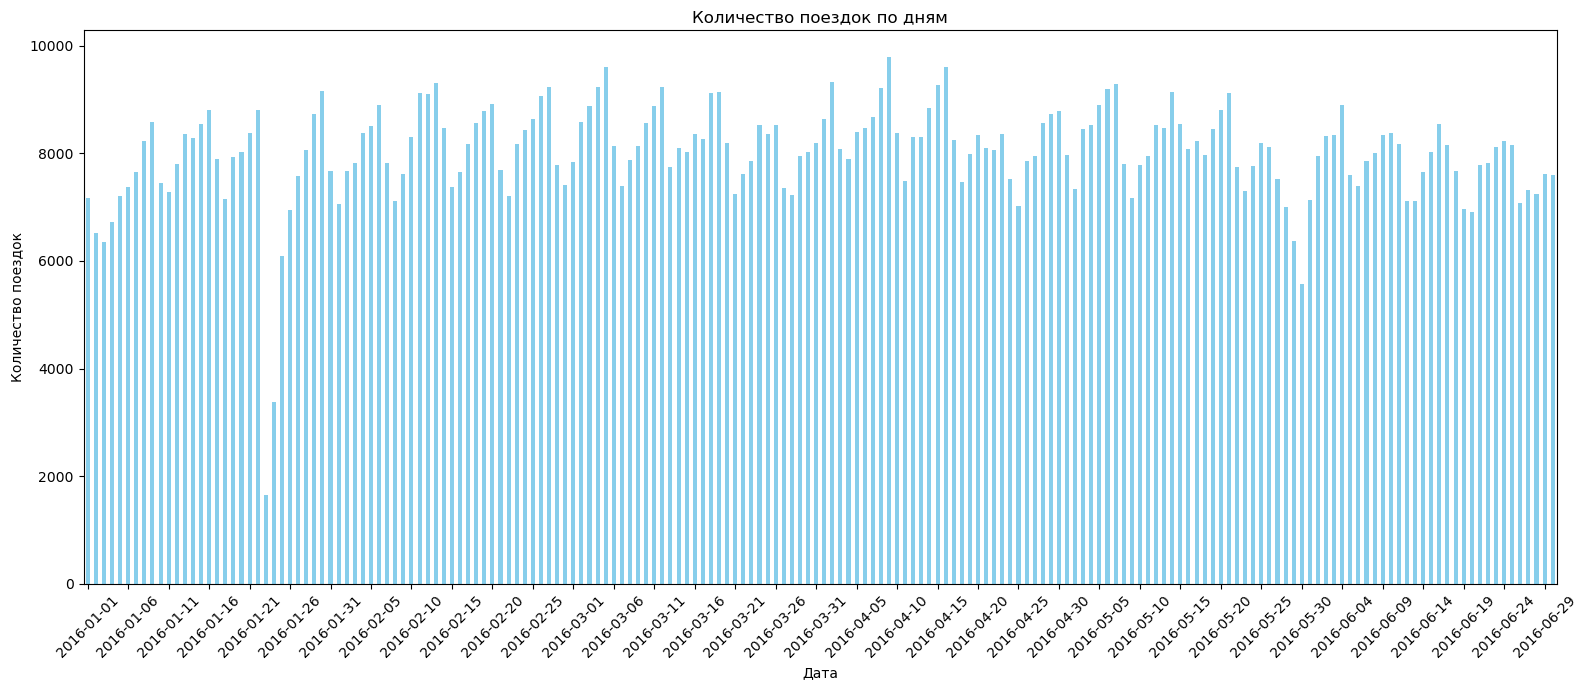

In [534]:
data['day'] = data['pickup_datetime'].dt.date
day = data.groupby('day').size()

plt.figure(figsize=(16, 7))
plt.grid()
day.plot(kind='bar', color='skyblue', width=0.5)
plt.title('Количество поездок по дням')
plt.xlabel('Дата')
plt.ylabel('Количество поездок')
plt.xticks(ticks=range(0, len(day), 5), labels=day.index[::5], rotation=45)
plt.tight_layout()
plt.show()

data.drop(columns=['day'], inplace=True)

**Вопрос**: Вы, вероятно, заметили, что на графике есть 2 периода с аномально маленькими количествами поездок. Вычислите, в какие даты происходили эти скачки вниз и найдите информацию о том, что происходило в эти дни в Нью-Йорке.

Нарисуйте графики зависимости количества поездок от дня недели и от часов в сутках:

In [535]:
day = day.reset_index()
day.columns = ['day', 'count']
day = day.sort_values(['count'])
day.head()

,day,count
22,2016-01-23,1648
23,2016-01-24,3383
150,2016-05-30,5570
24,2016-01-25,6084
2,2016-01-03,6353


Несложно понять, что в *2016-01-23* и *2016-05-30* что то случилось: соответственно снегопад и праздник

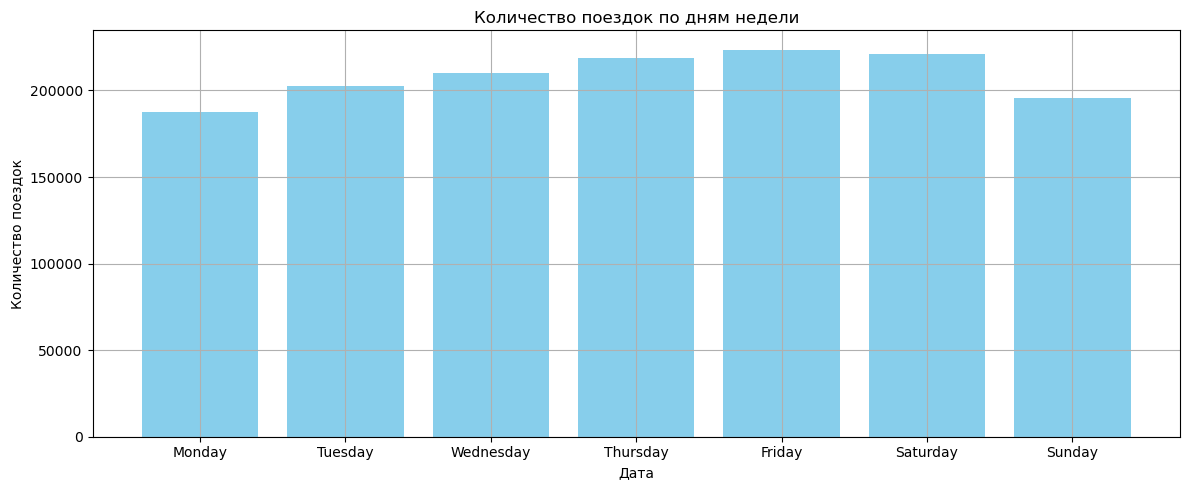

In [536]:
data['day'] = data['pickup_datetime'].dt.day_name()
day = data.groupby('day').size()
day = day.reset_index()
day.columns = ['day', 'count']
day = day.sort_values(['day'])

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day['day'] = day['day'].astype(str)
day['day'] = pd.Categorical(day['day'], categories=days_order, ordered=True)
sorted_df = day.sort_values(by='day').reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.grid()
plt.bar(sorted_df['day'], sorted_df['count'], color='skyblue')
plt.title('Количество поездок по дням недели')
plt.xlabel('Дата')
plt.ylabel('Количество поездок')
plt.tight_layout()
plt.show()

data.drop(columns=['day'], inplace=True)

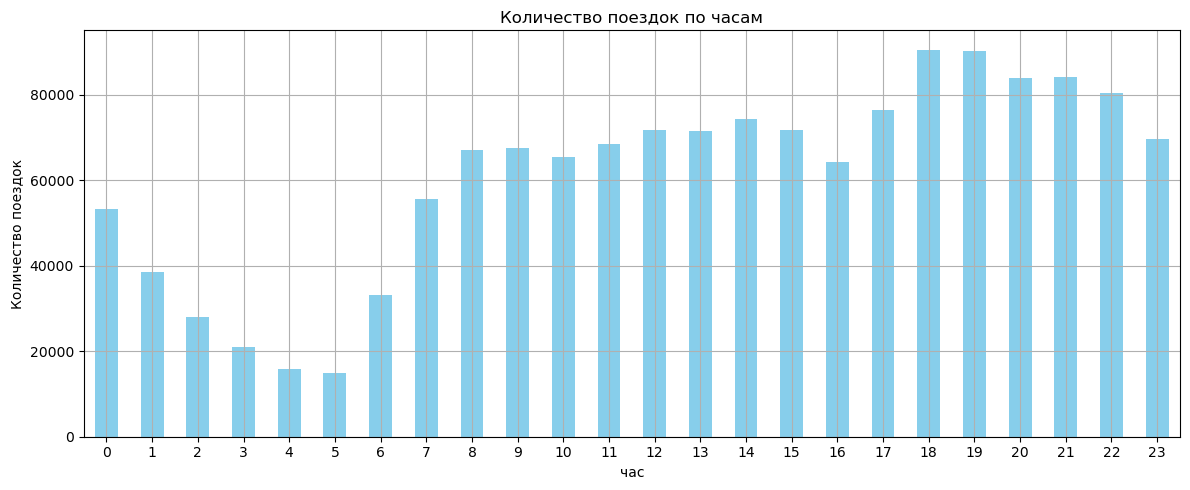

In [537]:
data['day'] = data['pickup_datetime'].dt.hour
day = data.groupby('day').size()

plt.figure(figsize=(12, 5))
day.plot(kind='bar', color='skyblue', width=0.5)
plt.grid()
plt.title('Количество поездок по часам')
plt.xlabel('час')
plt.ylabel('Количество поездок')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

data.drop(columns=['day'], inplace=True)

**Задание 3 (0.5 баллов)**. Нарисуйте на одном графике зависимости количества поездок от часа в сутках для разных месяцев (разные кривые, соответствующие разным месяцам, окрашивайте в разные цвета, поищите, как это делается). Аналогично нарисуйте зависимости количества поездок от часа в сутках для разных дней недели.

In [538]:
data['month'] = data['pickup_datetime'].dt.month
data['hour'] = data['pickup_datetime'].dt.hour

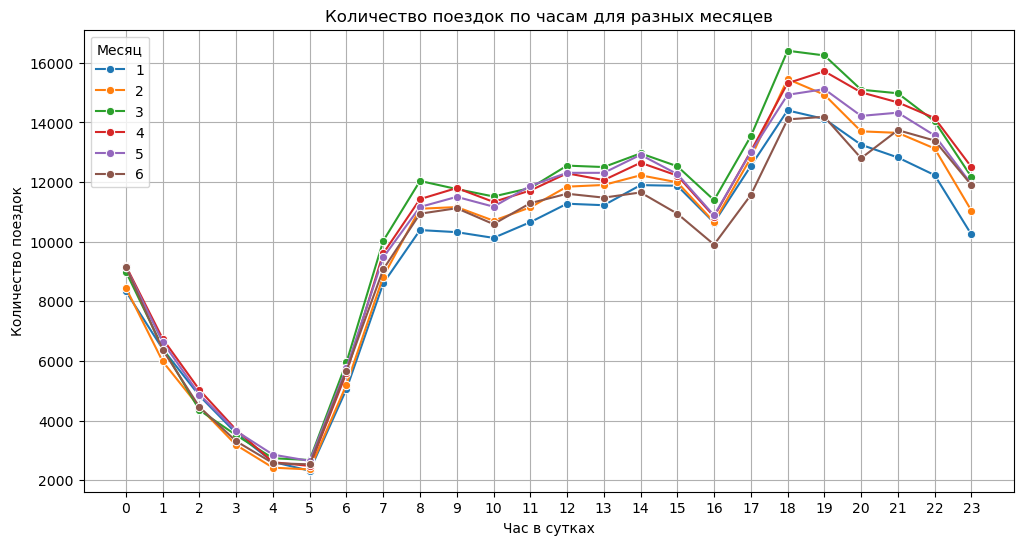

In [539]:
monthly_hour = data.groupby(['month', 'hour']).size().reset_index()
monthly_hour.rename(columns={0: 'count'}, inplace=True)

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_hour, x='hour', y='count', hue='month', palette='tab10', marker='o')
plt.title('Количество поездок по часам для разных месяцев')
plt.xlabel('Час в сутках')
plt.ylabel('Количество поездок')
plt.xticks(range(0, 24))  
plt.legend(title='Месяц')
plt.grid()
plt.show()

In [540]:
data['day'] = data['pickup_datetime'].dt.day_name()

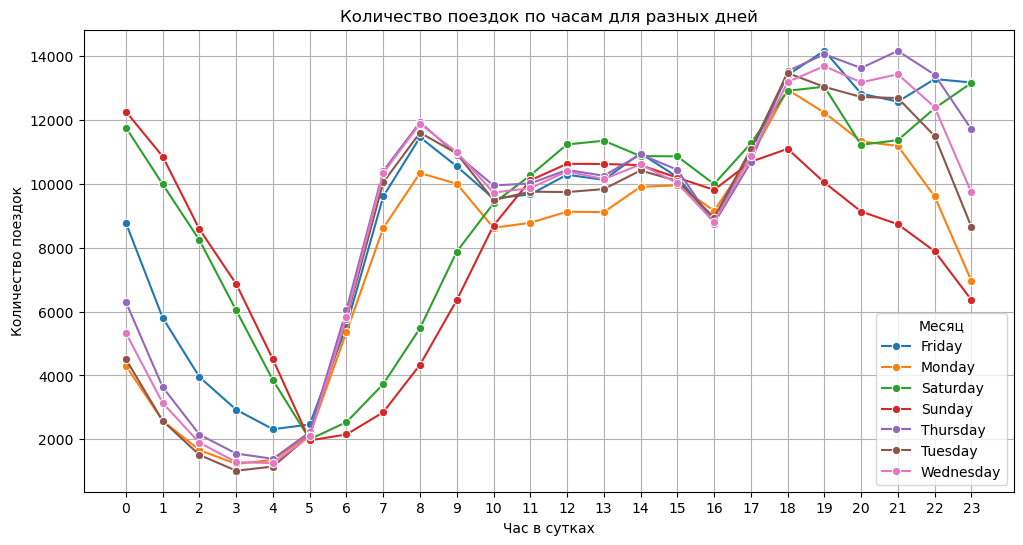

In [541]:
monthly_hour = data.groupby(['day', 'hour']).size().reset_index()
monthly_hour.rename(columns={0: 'count'}, inplace=True)

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_hour, x='hour', y='count', hue='day', palette='tab10', marker='o')
plt.title('Количество поездок по часам для разных дней')
plt.xlabel('Час в сутках')
plt.ylabel('Количество поездок')
plt.xticks(range(0, 24))  
plt.legend(title='Месяц')
plt.grid()
plt.show()

In [542]:
data.drop(columns=['day', 'month', 'hour'], inplace=True)

**Вопрос**: Какие выводы можно сделать, основываясь на графиках выше? Выделяются ли какие-нибудь дни недели? Месяца? Время суток? С чем это связано?

**Ответ**: Графики показывают, что количество поездок значительно увеличивается утром и вечером - пиковые часы для поездок, связанные с рабочими часами. График час/месяц показывает, что количество поездок не так сильно зависит от месяца. А в графике час/день показывает что пятница и суббота показывают более высокие значения поездок в вечерние часы, что может быть связано с выходами и развлекательными мероприятиями.

**Задание 4 (0.5 баллов)**. Разбейте выборку на обучающую и тестовую в отношении 7:3 (используйте `train_test_split` из `sklearn`). По обучающей выборке нарисуйте график зависимости среднего логарифма времени поездки от дня недели. Затем сделайте то же самое, но для часа в сутках и дня в году.

In [543]:
from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(data, test_size=0.3, random_state=42)

In [544]:
train_data.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,log_trip_duration
1011257,id2209155,2,2016-05-03 09:03:08,2,-73.979813,40.752529,-73.982681,40.763680,N,6.739337
178550,id0586605,1,2016-01-01 16:40:51,1,-73.977623,40.746296,-73.968414,40.788933,N,6.909753
551460,id0467144,1,2016-04-24 13:57:03,1,-73.950699,40.779404,-73.863129,40.768608,N,6.955593
1434271,id0989010,2,2016-01-10 17:03:47,1,-73.984558,40.721802,-73.976753,40.752213,N,6.665684
1173610,id0580742,1,2016-02-25 17:37:36,1,-73.967720,40.768742,-73.977173,40.789875,N,6.597146


In [545]:
train_data['month'] = train_data['pickup_datetime'].dt.month
train_data['hour'] = train_data['pickup_datetime'].dt.hour
train_data['day'] = train_data['pickup_datetime'].dt.dayofweek
train_data['day_year'] = train_data['pickup_datetime'].dt.dayofyear

In [546]:
test_data['month'] = test_data['pickup_datetime'].dt.month
test_data['hour'] = test_data['pickup_datetime'].dt.hour
test_data['day'] = test_data['pickup_datetime'].dt.dayofweek
test_data['day_year'] = test_data['pickup_datetime'].dt.dayofyear

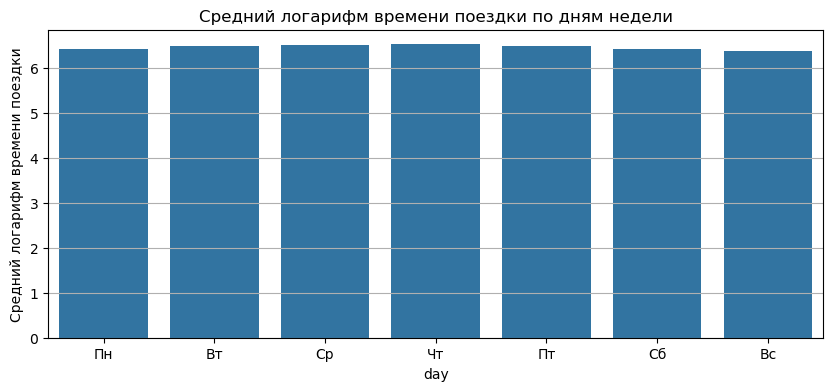

In [547]:
plt.figure(figsize=(10, 4))
plt.grid()
sns.barplot(x='day', y='log_trip_duration', data=train_data.groupby('day')['log_trip_duration'].mean().reset_index())
plt.title('Средний логарифм времени поездки по дням недели')
plt.ylabel('Средний логарифм времени поездки')
plt.xticks(ticks=np.arange(7), labels=['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])
plt.show()

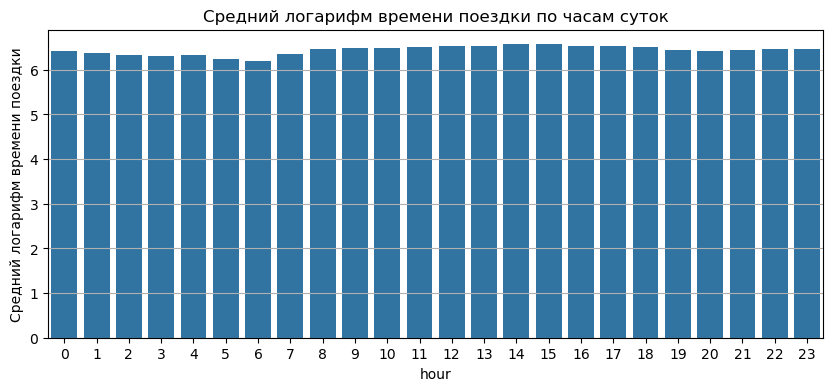

In [548]:
plt.figure(figsize=(10, 4))
plt.grid(True)
sns.barplot(x='hour', y='log_trip_duration', data=train_data.groupby('hour')['log_trip_duration'].mean().reset_index())
plt.title('Средний логарифм времени поездки по часам суток')
plt.ylabel('Средний логарифм времени поездки')
plt.show()

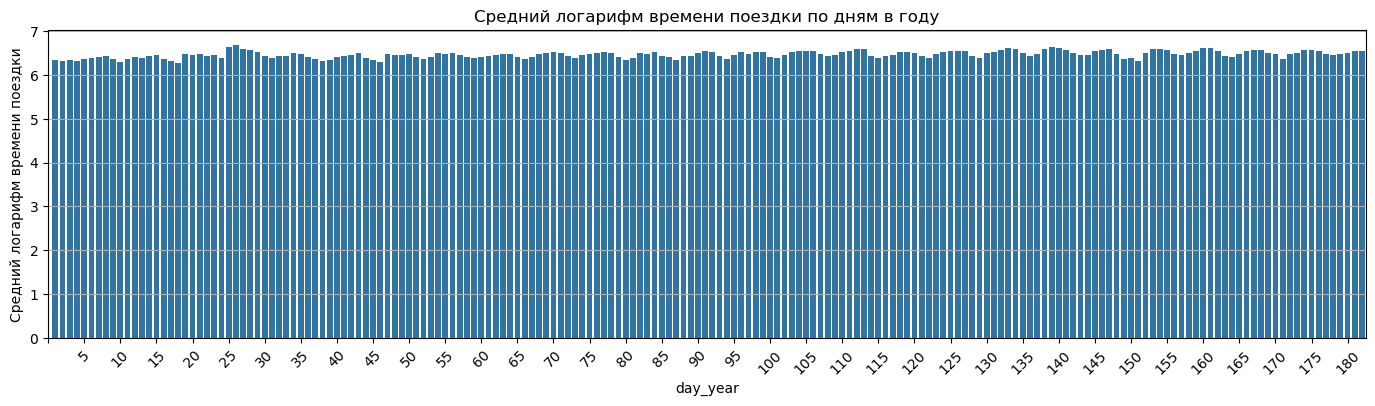

In [549]:
plt.figure(figsize=(17, 4))
plt.grid()
sns.barplot(x='day_year', y='log_trip_duration', data=train_data.groupby('day_year')['log_trip_duration'].mean().reset_index())
plt.title('Средний логарифм времени поездки по дням в году')
plt.ylabel('Средний логарифм времени поездки')
plt.xticks(ticks=range(-1, 182, 5), rotation=45)
plt.show()

**Вопрос**: Похожи ли графики зависимости таргета от дня недели и от часа в сутках на аналогичные графики для количества поездок? Почему? Что происходит со средним таргетом в те два аномальных периода, что мы видели выше? Почему так происходит? Наблюдаете ли вы какой-нибудь тренд на графике зависимости `log_trip_duration` от номера дня в году?

**Ответ**: Графики зависимости таргета от дня недели и от часа в сутках на аналогичные графики для количества поездок не похожи, так как мы брали логарифм, значит данные будут не так сильно отличаться как без логарифма. В те два аномальных периода тоже ничего особенного. На графике зависимости `log_trip_duration` от номера дня в году периодический (недели)

Добавьте следующие признаки на основе `pickup_datetime`:
1. День недели
2. Месяц
3. Час
4. Является ли период аномальным (два бинарных признака, соответствующие двум аномальным периодам)
5. Номер дня в году

In [550]:
train_data['is_special_day'] = False
special_dates = pd.to_datetime(["2016-01-23", "2016-05-30"]).date
train_data.loc[
    train_data['pickup_datetime'].dt.date.isin(special_dates), 
    'is_special_day'
] = True

In [551]:
train_data.rename(columns={
    'day': 'day_week',
}, inplace=True)
train_data.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,log_trip_duration,month,hour,day_week,day_year,is_special_day
1011257,id2209155,2,2016-05-03 09:03:08,2,-73.979813,40.752529,-73.982681,40.763680,N,6.739337,5,9,1,124,False
178550,id0586605,1,2016-01-01 16:40:51,1,-73.977623,40.746296,-73.968414,40.788933,N,6.909753,1,16,4,1,False
551460,id0467144,1,2016-04-24 13:57:03,1,-73.950699,40.779404,-73.863129,40.768608,N,6.955593,4,13,6,115,False
1434271,id0989010,2,2016-01-10 17:03:47,1,-73.984558,40.721802,-73.976753,40.752213,N,6.665684,1,17,6,10,False
1173610,id0580742,1,2016-02-25 17:37:36,1,-73.967720,40.768742,-73.977173,40.789875,N,6.597146,2,17,3,56,False


In [552]:
test_data['is_special_day'] = False
special_dates = pd.to_datetime(["2016-01-23", "2016-05-30"]).date
test_data.loc[
    test_data['pickup_datetime'].dt.date.isin(special_dates), 
    'is_special_day'
] = True

test_data.rename(columns={
    'day': 'day_week',
}, inplace=True)

Итак, мы уже создали некоторое количество признаков.

**Вопрос**: Какие из признаков _стоит рассматривать в этой задаче_   как категориальные, а какие - как численные? Почему?

**Ответ**: 

Численные - month, hour, day_week так как каждый из них означают какой то немаленький период времени, а day_year почти не меняется.

Категориальные - is_special_day, так как в нем тольео да или нет. 

**Задание 5 (0.75 баллов)**. Обучите `Ridge`-регрессию с параметрами по умолчанию, закодировав все категориальные признаки с помощью `OneHotEncoder`. Численные признаки отмасштабируйте с помощью `StandardScaler`. Используйте только признаки, которые мы выделили в этой части задания.

In [553]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


X_train = train_data[['month', 'hour', 'day_week', 'is_special_day']]
y_train = train_data['log_trip_duration']

y_test = test_data['log_trip_duration']
X_test = test_data[['month', 'hour', 'day_week', 'is_special_day']]

categorical_features = ['is_special_day']
numerical_features = ['month', 'hour', 'day_week']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print("RMSLE:", rmsle(y_test, y_pred))
print("RMSLE_best:", rmsle_best_const)

RMSLE: 0.793293815478173
RMSLE_best: 0.7957592365411509


## Часть 2. Изучаем координаты (3 балла)
Мы уже очень хорошо изучили данные о времени начала поездки, давайте теперь посмотрим на информацию о координатах начала и конца поездки. Мы подготовили для вас функцию, которая на карте рисует точки начала или конца поездки. Примеры ее вызова вы найдете ниже. Обратите внимание, что в эту функцию мы передаем лишь небольшой кусочек данных, посколько иначе функция будет работать очень долго

In [554]:
from typing import Iterable

def show_circles_on_map(
    latitude_values: Iterable[float],
    longitude_values: Iterable[float],
    color: str = "blue",
) -> folium.Map:
    """
    The function draws map with circles on it.
    The center of the map is the mean of coordinates passed in data.
    Works best on samples of size < 10k, too costly otherwise

    latitude_values: sample latitude values of a dataframe
    longitude_column: sample longitude values of a dataframe
    color: the color of circles to be drawn
    """

    location = (np.mean(latitude_values), np.mean(longitude_values))
    m = folium.Map(location=location)

    for lat, lon in zip(latitude_values, longitude_values):
        folium.Circle(
            radius=100,
            location=(lat, lon),
            color=color,
            fill_color=color,
            fill=True
        ).add_to(m)

    return m

Напишите функция, которая вернет значения колонок `pickup_latitude`, `pickup_longitude` на каком-нибудь разумном кусочке датафрейма, например, `df.sample(1000)` и покажите на карте, используя `show_circles_on_map`

In [555]:
df = data.sample(1000)
your_lat_values = df['pickup_latitude']
your_lon_values = df['pickup_longitude']

show_circles_on_map(your_lat_values, your_lon_values, color="midnightblue")

**Вопрос**: Какие пункты (или скопления точек, в количестве 2-3), по вашему мнению, выделяются на карте от основной массы и могут быть полезны для нашей задачи? Почему вы их выбрали? В чём особенность этих скоплений точек для нашей задачи?

**Ответ**: Главные пункты: аэропорты - длина поездки будет длинным и сильно отличаться от остальных.

**Задание 6 (0.75 балл)**. Как мы все прекрасно помним, $t = s / v_{\text{ср}}$, поэтому очевидно, что самым сильным признаком будет расстояние, которое необходимо проехать. Мы не можем посчитать точное расстояние, которое необходимо преодолеть такси, но мы можем его оценить, посчитав кратчайшее расстояние между точками начала и конца поездки. Чтобы корректно посчитать расстояние между двумя точками на Земле, можно использовать функцию `haversine`. Также можно воспользоваться кодом с первого семинара. Посчитайте кратчайшее расстояние для объектов и запишите его в колонку `haversine`:

In [556]:
def haversine_array(lat1, lng1, lat2, lng2):
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    AVG_EARTH_RADIUS = 6371  # in km
    lat = lat2 - lat1
    lng = lng2 - lng1
    d = np.sin(lat * 0.5) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(lng * 0.5) ** 2
    h = 2 * AVG_EARTH_RADIUS * np.arcsin(np.sqrt(d))
    return h

test_data['haversine'] = haversine_array(
    test_data['pickup_latitude'].values,
    test_data['pickup_longitude'].values,
    test_data['dropoff_latitude'].values,
    test_data['dropoff_longitude'].values,
)

train_data['haversine'] = haversine_array(
    train_data['pickup_latitude'].values,
    train_data['pickup_longitude'].values,
    train_data['dropoff_latitude'].values,
    train_data['dropoff_longitude'].values,
)
train_data.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,log_trip_duration,month,hour,day_week,day_year,is_special_day,haversine
1011257,id2209155,2,2016-05-03 09:03:08,2,-73.979813,40.752529,-73.982681,40.763680,N,6.739337,5,9,1,124,False,1.263187
178550,id0586605,1,2016-01-01 16:40:51,1,-73.977623,40.746296,-73.968414,40.788933,N,6.909753,1,16,4,1,False,4.804012
551460,id0467144,1,2016-04-24 13:57:03,1,-73.950699,40.779404,-73.863129,40.768608,N,6.955593,4,13,6,115,False,7.471088
1434271,id0989010,2,2016-01-10 17:03:47,1,-73.984558,40.721802,-73.976753,40.752213,N,6.665684,1,17,6,10,False,3.444869
1173610,id0580742,1,2016-02-25 17:37:36,1,-73.967720,40.768742,-73.977173,40.789875,N,6.597146,2,17,3,56,False,2.481063


Так как мы предсказываем логарифм времени поездки и хотим, чтобы наши признаки были линейно зависимы с этой целевой переменной, нам нужно логарифмировать расстояние: $\log t = \log s - \log{v_{\text{ср}}}$. Запишите логарифм `haversine` в отдельную колонку `log_haversine`:

In [557]:
train_data['log_haversine'] = np.log1p(train_data['haversine'])
test_data['log_haversine'] = np.log1p(test_data['haversine'])

Посчитайте корреляцию и убедитесь, что логарифм расстояния лучше отражает таргет, чем просто расстояние:

In [558]:
log_correlation = train_data['log_haversine'].corr(train_data['log_trip_duration'])
print("Корреляция_log:", log_correlation)

correlation = train_data['haversine'].corr(train_data['log_trip_duration'])
print("Корреляция:", correlation)

Корреляция_log: 0.7499594955685643
Корреляция: 0.565405987389023


**Задание 7 (0.75 балла)**. Давайте изучим среднюю скорость движения такси. Посчитайте среднюю скорость для каждого объекта обучающей выборки, разделив `haversine` на `trip_duration`, и нарисуйте гистограмму ее распределения

In [559]:
train_data['v'] = train_data['haversine'] / np.expm1(train_data['log_trip_duration'])
train_data.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,log_trip_duration,month,hour,day_week,day_year,is_special_day,haversine,log_haversine,v
1011257,id2209155,2,2016-05-03 09:03:08,2,-73.979813,40.752529,-73.982681,40.763680,N,6.739337,5,9,1,124,False,1.263187,0.816774,0.001497
178550,id0586605,1,2016-01-01 16:40:51,1,-73.977623,40.746296,-73.968414,40.788933,N,6.909753,1,16,4,1,False,4.804012,1.758549,0.004799
551460,id0467144,1,2016-04-24 13:57:03,1,-73.950699,40.779404,-73.863129,40.768608,N,6.955593,4,13,6,115,False,7.471088,2.136659,0.007129
1434271,id0989010,2,2016-01-10 17:03:47,1,-73.984558,40.721802,-73.976753,40.752213,N,6.665684,1,17,6,10,False,3.444869,1.491750,0.004394
1173610,id0580742,1,2016-02-25 17:37:36,1,-73.967720,40.768742,-73.977173,40.789875,N,6.597146,2,17,3,56,False,2.481063,1.247338,0.003389


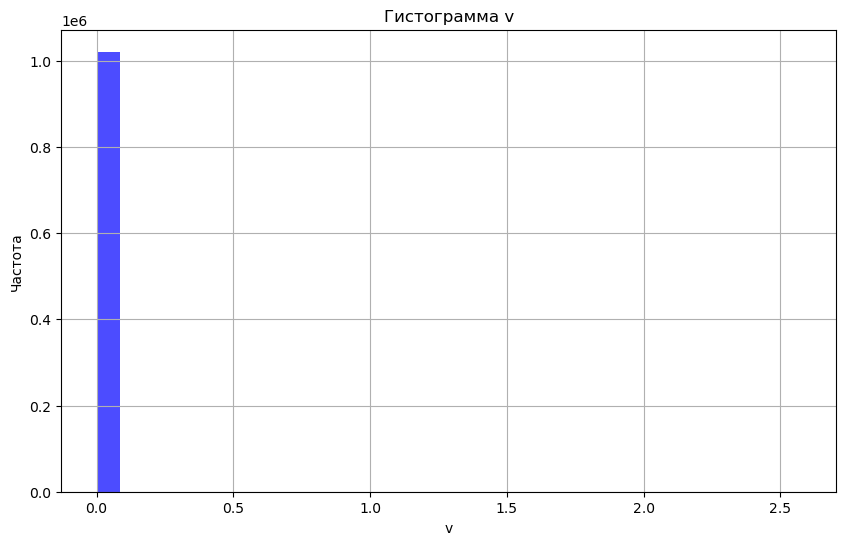

In [560]:
plt.figure(figsize=(10, 6))
plt.grid()
plt.hist(train_data['v'], bins=30, color='blue', alpha=0.7)
plt.title('Гистограмма v')
plt.xlabel('v')
plt.ylabel('Частота')
plt.show()

Как можно видеть по гистограмме, для некоторых объектов у нас получились очень больше значения скоростей. Нарисуйте гистограмму по объектам, для которых значение скорости получилось разумным (например, можно не включать рассмотрение объекты, где скорость больше некоторой квантили):

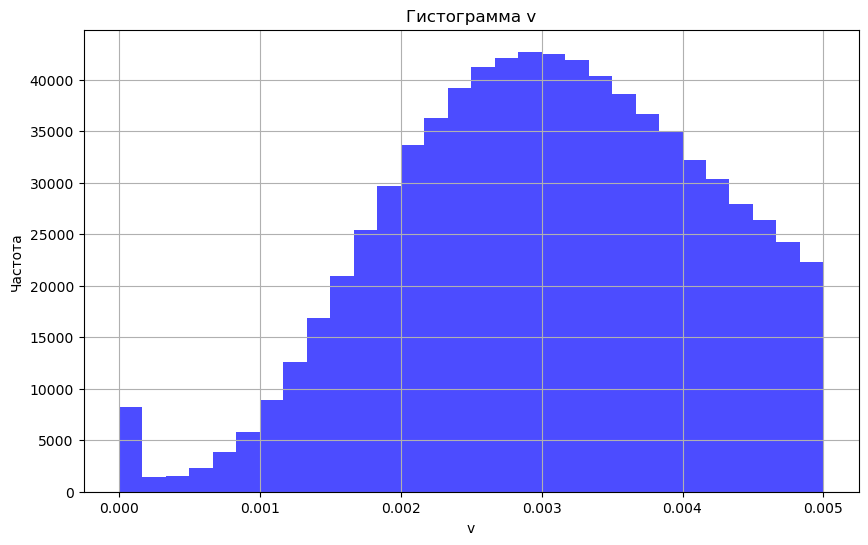

In [561]:
plt.figure(figsize=(10, 6))
plt.grid()
plt.hist(train_data['v'][train_data['v'] < 0.005], bins=30, color='blue', alpha=0.7)
plt.title('Гистограмма v')
plt.xlabel('v')
plt.ylabel('Частота')
plt.show()

Для каждой пары (день недели, час суток) посчитайте медиану скоростей. Нарисуйте Heatmap-график, где по осям будут дни недели и часы, а в качестве значения функции - медиана скорости

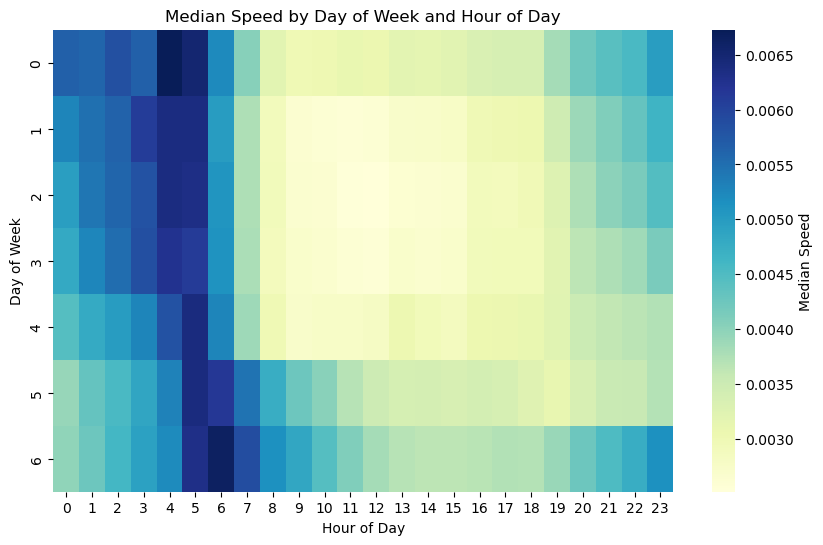

In [562]:
median_speeds = train_data.groupby(['day_week', 'hour'])['v'].median().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(median_speeds, annot=False, cmap='YlGnBu', cbar_kws={'label': 'Median Speed'})
plt.title('Median Speed by Day of Week and Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

Не забудьте удалить колонку со значением скорости из данных!

**Вопрос**: Почему значение скорости нельзя использовать во время обучения?

**Ответ**: Использование скорости может привести к избыточности информации. Это может затруднить обучение и ухудшить ее способность.

In [563]:
train_data.drop(columns=['v'], inplace=True)

**Вопрос**: Посмотрите внимательно на график и скажите, в какие моменты времени скорость минимальна; максимальна.

**Ответ**: 

Скорость максимальна - будни с 4-5 / выходные с 5-6

Скорость минимальна - будни с 8-18

Создайте признаки "поездка совершается в период пробок" и "поездка совершается в период свободных дорог" (естественно, они не должен зависеть от скорости!):

In [564]:
train_data['is_traffic'] = False
train_data.loc[
    (0 <= train_data['day_week']) & (train_data['day_week'] <= 4) & 
    (8 <= train_data['hour']) & (train_data['hour'] <= 18), 
    'is_traffic'
] = True


train_data['is_free'] = False
train_data.loc[
    ((0 <= train_data['day_week']) & (train_data['day_week'] <= 4) & 
    (4 <= train_data['hour']) & (train_data['hour'] <= 5)) |
    ((5 <= train_data['day_week']) & (train_data['day_week'] <= 6) & 
    (5 <= train_data['hour']) & (train_data['hour'] <= 6)), 
    'is_free'
] = True

In [565]:
test_data['is_traffic'] = False
test_data.loc[
    (0 <= test_data['day_week']) & (test_data['day_week'] <= 4) & 
    (8 <= test_data['hour']) & (test_data['hour'] <= 18), 
    'is_traffic'
] = True


test_data['is_free'] = False
test_data.loc[
    ((0 <= test_data['day_week']) & (test_data['day_week'] <= 4) & 
    (4 <= test_data['hour']) & (test_data['hour'] <= 5)) |
    ((5 <= test_data['day_week']) & (test_data['day_week'] <= 6) & 
    (5 <= test_data['hour']) & (test_data['hour'] <= 6)), 
    'is_free'
] = True

In [566]:
train_data.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,log_trip_duration,month,hour,day_week,day_year,is_special_day,haversine,log_haversine,is_traffic,is_free
1011257,id2209155,2,2016-05-03 09:03:08,2,-73.979813,40.752529,-73.982681,40.763680,N,6.739337,5,9,1,124,False,1.263187,0.816774,True,False
178550,id0586605,1,2016-01-01 16:40:51,1,-73.977623,40.746296,-73.968414,40.788933,N,6.909753,1,16,4,1,False,4.804012,1.758549,True,False
551460,id0467144,1,2016-04-24 13:57:03,1,-73.950699,40.779404,-73.863129,40.768608,N,6.955593,4,13,6,115,False,7.471088,2.136659,False,False
1434271,id0989010,2,2016-01-10 17:03:47,1,-73.984558,40.721802,-73.976753,40.752213,N,6.665684,1,17,6,10,False,3.444869,1.491750,False,False
1173610,id0580742,1,2016-02-25 17:37:36,1,-73.967720,40.768742,-73.977173,40.789875,N,6.597146,2,17,3,56,False,2.481063,1.247338,True,False


**Задание 8 (0.25 балла)**. Для каждого из замеченных вами выше 2-3 пунктов добавьте в выборку по два признака:
- началась ли поездка в этом пункте
- закончилась ли поездка в этом пункте

Как вы думаете, почему эти признаки могут быть полезны? По времени поездки они будут отличаться от времени поездки с дргуими. 

In [567]:
train_data['airport_1_pick'] = False
train_data['airport_1_drop'] = False
train_data['airport_2_pick'] = False
train_data['airport_2_drop'] = False

In [568]:
test_data['airport_1_pick'] = False
test_data['airport_1_drop'] = False
test_data['airport_2_pick'] = False
test_data['airport_2_drop'] = False

In [569]:
jfk_bounds = (40.6413, 40.6500, -73.8100, -73.7781)
lga_bounds = (40.7690, 40.7850, -73.8700, -73.8500)

train_data.loc[
    (jfk_bounds[0] <= train_data['pickup_latitude']) &
    (train_data['pickup_latitude'] <= jfk_bounds[1]) &
    (jfk_bounds[2] <= train_data['pickup_longitude']) &
    (train_data['pickup_longitude'] <= jfk_bounds[3]),
    'airport_1_pick'
] = True

train_data.loc[
    (jfk_bounds[0] <= train_data['dropoff_latitude']) &
    (train_data['dropoff_latitude'] <= jfk_bounds[1]) &
    (jfk_bounds[2] <= train_data['dropoff_longitude']) &
    (train_data['dropoff_longitude'] <= jfk_bounds[3]),
    'airport_1_drop'
] = True

train_data.loc[
    (lga_bounds[0] <= train_data['pickup_latitude']) &
    (train_data['pickup_latitude'] <= lga_bounds[1]) &
    (lga_bounds[2] <= train_data['pickup_longitude']) &
    (train_data['pickup_longitude'] <= lga_bounds[3]),
    'airport_2_pick'
] = True

train_data.loc[
    (lga_bounds[0] <= train_data['dropoff_latitude']) &
    (train_data['dropoff_latitude'] <= lga_bounds[1]) &
    (lga_bounds[2] <= train_data['dropoff_longitude']) &
    (train_data['dropoff_longitude'] <= lga_bounds[3]),
    'airport_2_drop'
] = True

In [570]:
jfk_bounds = (40.6413, 40.6500, -73.8100, -73.7781)
lga_bounds = (40.7690, 40.7850, -73.8700, -73.8500)

test_data.loc[
    (jfk_bounds[0] <= test_data['pickup_latitude']) &
    (test_data['pickup_latitude'] <= jfk_bounds[1]) &
    (jfk_bounds[2] <= test_data['pickup_longitude']) &
    (test_data['pickup_longitude'] <= jfk_bounds[3]),
    'airport_1_pick'
] = True

test_data.loc[
    (jfk_bounds[0] <= test_data['dropoff_latitude']) &
    (test_data['dropoff_latitude'] <= jfk_bounds[1]) &
    (jfk_bounds[2] <= test_data['dropoff_longitude']) &
    (test_data['dropoff_longitude'] <= jfk_bounds[3]),
    'airport_1_drop'
] = True

test_data.loc[
    (lga_bounds[0] <= test_data['pickup_latitude']) &
    (test_data['pickup_latitude'] <= lga_bounds[1]) &
    (lga_bounds[2] <= test_data['pickup_longitude']) &
    (test_data['pickup_longitude'] <= lga_bounds[3]),
    'airport_2_pick'
] = True

test_data.loc[
    (lga_bounds[0] <= test_data['dropoff_latitude']) &
    (test_data['dropoff_latitude'] <= lga_bounds[1]) &
    (lga_bounds[2] <= test_data['dropoff_longitude']) &
    (test_data['dropoff_longitude'] <= lga_bounds[3]),
    'airport_2_drop'
] = True

Для каждого из созданных признаков нарисуйте "ящик с усами" (aka boxplot) распределения логарифма времени поездки

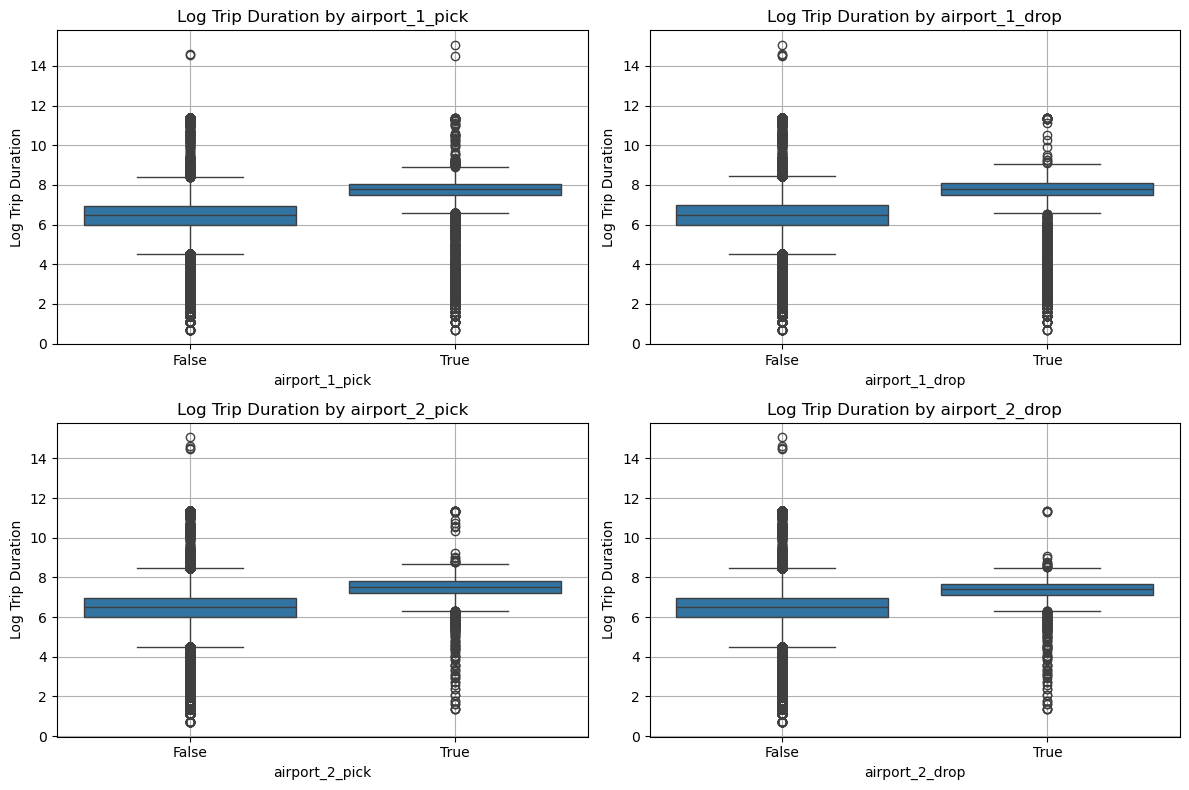

In [571]:
airport_features = ['airport_1_pick', 'airport_1_drop', 'airport_2_pick', 'airport_2_drop']

plt.figure(figsize=(12, 8))

for i, feature in enumerate(airport_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=train_data[feature], y=train_data['log_trip_duration'])
    plt.title(f'Log Trip Duration by {feature}')
    plt.xlabel(feature)
    plt.grid()
    plt.ylabel('Log Trip Duration')

plt.tight_layout()
plt.show()

**Вопрос**: судя по графикам, как вы думаете, хорошими ли получились эти признаки?

**Ответ**: Да, полуичились хорошими, так как поездки в/из эти пунктов занимает больше времени.

<img src="https://www.dropbox.com/s/xson9nukz5hba7c/map.png?raw=1" align="right" width="20%" style="margin-left: 20px; margin-bottom: 20px">

**Задание 9 (1 балл)**. Сейчас мы почти что не используем сами значения координат. На это есть несколько причин: по отдельности рассматривать широту и долготу не имеет особого смысла, стоит рассматривать их вместе. Во-вторых, понятно, что зависимость между нашим таргетом и координатами не линейная. Чтобы как-то использовать координаты, можно прибегнуть к следующему трюку: обрамим область с наибольшим количеством поездок прямоугольником (как на рисунке). Разобьем этот прямоугольник на ячейки. Каждой точке сопоставим номер ее ячейки, а тем точкам, что не попали ни в одну из ячеек, сопоставим значение -1.

Напишите трансформер, который сначала разбивает показанную на рисунке область на ячейки, а затем создает два признака: номер ячейки, в которой началась поездка, и номер ячейки, в которой закончилась поездка. Количество строк и столбцов выберите самостоятельно.

Обратите внимание, что все вычисления должны быть векторизованными, трансформер не должен модифицировать передаваемую ему выборку inplace, а все необходимые статистики (если они вдруг нужны) нужно считать только по обучающей выборке в методе `fit`:

In [572]:
from sklearn.base import BaseEstimator, TransformerMixin


# TransformerMixin implements fit_transform for you,
# applying your fit and transform consistently
#40.706819, -74.012164
#40,80211, -73,93094

#print(train_data.describe())
#train_data.drop(columns=['pickup_cell', 'dropoff_cell'],inplace=True)

class MapGridTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_rows, n_cols):
        self.n_rows = n_rows
        self.n_cols = n_cols
        self.lat_min = 40.700819
        self.lat_max = 40.80211
        self.lon_min = -74.021164
        self.lon_max = -73.93094
        self.grid = None
        self.lat_bin_size = 0
        self.lon_bin_size = 0

    def show_map(self, latitude_values: Iterable[float], longitude_values: Iterable[float]):
        m = folium.Map(location=[(self.lat_min + self.lat_max) / 2, (self.lon_min + self.lon_max) / 2], zoom_start=13)

        lat_edges = np.linspace(self.lat_min, self.lat_max, self.n_rows + 1)
        lon_edges = np.linspace(self.lon_min, self.lon_max, self.n_cols + 1)
        
        location = (np.mean(latitude_values), np.mean(longitude_values))
        for lat, lon in zip(latitude_values, longitude_values):
            check = transformed_df['pickup_cell'][(transformed_df['pickup_latitude'] == lat)&(transformed_df['pickup_longitude'] == lon)]
            if check.isin([1]).any():
                color = 'pink'
            elif check.isin([2]).any():
                color = 'blue'
            elif check.isin([3]).any():
                color = 'green'
            elif check.isin([4]).any():
                color = 'orange'
            elif check.isin([5]).any():
                color = 'purple'
            elif check.isin([6]).any():
                color = 'yellow'
            elif check.isin([7]).any():
                color = 'brown'
            elif check.isin([8]).any():
                color = 'gray'
            elif check.isin([9]).any():
                color = 'black'
            elif check.isin([10]).any():
                color = 'white'
            elif check.isin([11]).any():
                color = 'cyan'
            elif check.isin([12]).any():
                color = 'magenta'
            elif check.isin([13]).any():
                color = 'red'
            elif check.isin([14]).any():
                color = 'lime'
            elif check.isin([15]).any():
                color = 'navy'
            elif check.isin([16]).any():
                color = 'teal'
            else:
                color = 'black'
            folium.Circle(
                radius=100,
                location=(lat, lon),
                color=color,
                fill_color=color,
                fill=True
            ).add_to(m)

        for i in range(self.n_rows):
            for j in range(self.n_cols):

                lat1 = lat_edges[i]
                lat2 = lat_edges[i + 1]
                lon1 = lon_edges[j]
                lon2 = lon_edges[j + 1]

                folium.Rectangle(
                    bounds=[[lat1, lon1], [lat2, lon2]],
                    color='red',
                    fill=False,
                    weight=3,  
                    opacity=0.8
                ).add_to(m)

                lat_center = (lat1 + lat2) / 2
                lon_center = (lon1 + lon2) / 2

        return m

    def fit(self, X=None, y=None):
        self.grid = np.zeros((self.n_rows, self.n_cols))
        
        self.lat_bin_size = (self.lat_max - self.lat_min) / self.n_rows
        self.lon_bin_size = (self.lon_max - self.lon_min) / self.n_cols

        return self


    def transform(self, X_dt, y=None):
        
        X = X_dt.copy()
        self.grid = np.zeros((self.n_rows, self.n_cols))
        mask_drop = (self.lat_min <= X['dropoff_latitude']) & (X['dropoff_latitude'] <= self.lat_max) & (self.lon_min <= X['dropoff_longitude']) & (X['dropoff_longitude'] <= self.lon_max)
        mask_pick = (self.lat_min <= X['pickup_latitude']) & (X['pickup_latitude'] <= self.lat_max) & (self.lon_min <= X['pickup_longitude']) & (X['pickup_longitude'] <= self.lon_max)

        X['pickup_cell_lat'] = -1
        X['pickup_cell_lon'] = -1
        X['dropoff_cell_lat'] = -1
        X['dropoff_cell_lon'] = -1
        X['dropoff_cell'] = -1
        X['pickup_cell'] = -1

        array = np.arange(1, self.n_rows * self.n_cols + 1).reshape(self.n_rows, self.n_cols)

        lat_bin_size = self.lat_bin_size
        lon_bin_size = self.lon_bin_size

        X.loc[mask_pick, 'pickup_cell_lat'] = (abs(X['pickup_latitude'][mask_pick] - self.lat_min) * 100 / (lat_bin_size * 100)).astype(int)
        X.loc[mask_pick, 'pickup_cell_lon'] = (abs(X['pickup_longitude'][mask_pick] - self.lon_min) * 100 / (lon_bin_size * 100)).astype(int)

        X.loc[mask_drop, 'dropoff_cell_lat'] = (abs(X['dropoff_latitude'][mask_drop] - self.lat_min) * 100 / (lat_bin_size * 100)).astype(int)
        X.loc[mask_drop, 'dropoff_cell_lon'] = (abs(X['dropoff_longitude'][mask_drop] - self.lon_min) * 100 / (lon_bin_size * 100)).astype(int)

        pickup_lat_indices = X['pickup_cell_lat'][mask_pick].values
        pickup_lon_indices = X['pickup_cell_lon'][mask_pick].values
        X.loc[mask_pick, 'pickup_cell'] = array[pickup_lat_indices, pickup_lon_indices]

        dropoff_lat_indices = X['dropoff_cell_lat'][mask_drop].values
        dropoff_lon_indices = X['dropoff_cell_lon'][mask_drop].values
        X.loc[mask_drop, 'dropoff_cell'] = array[dropoff_lat_indices, dropoff_lon_indices]
        
        X.drop(columns=['pickup_cell_lat', 'pickup_cell_lon', 'dropoff_cell_lat', 'dropoff_cell_lon'],inplace=True)
        
        return X

transformer = MapGridTransformer(n_rows=4, n_cols=4)
transformer.fit(train_data)
transformed_df = transformer.transform(train_data)

transformer_test = MapGridTransformer(n_rows=4, n_cols=4)
transformer_test.fit(test_data)
transformed_test_df = transformer_test.transform(test_data)

test = transformed_df.sample(1000)
your_lat_values = test['pickup_latitude']
your_lon_values = test['pickup_longitude']
transformer.show_map(your_lat_values, your_lon_values)

**Задание 10 (0.25 балла)**. Обучите `Ridge`-регрессию со стандартными параметрами на признаках, которые мы выделили к текущему моменту. Категориальные признаки закодируйте через one-hot-кодирование, числовые признаки отмасштабируйте.

In [573]:
transformed_df.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,log_trip_duration,...,haversine,log_haversine,is_traffic,is_free,airport_1_pick,airport_1_drop,airport_2_pick,airport_2_drop,dropoff_cell,pickup_cell
1011257,id2209155,2,2016-05-03 09:03:08,2,-73.979813,40.752529,-73.982681,40.763680,N,6.739337,...,1.263187,0.816774,True,False,False,False,False,False,10,10
178550,id0586605,1,2016-01-01 16:40:51,1,-73.977623,40.746296,-73.968414,40.788933,N,6.909753,...,4.804012,1.758549,True,False,False,False,False,False,15,6
551460,id0467144,1,2016-04-24 13:57:03,1,-73.950699,40.779404,-73.863129,40.768608,N,6.955593,...,7.471088,2.136659,False,False,False,False,False,False,-1,16
1434271,id0989010,2,2016-01-10 17:03:47,1,-73.984558,40.721802,-73.976753,40.752213,N,6.665684,...,3.444869,1.491750,False,False,False,False,False,False,10,2
1173610,id0580742,1,2016-02-25 17:37:36,1,-73.967720,40.768742,-73.977173,40.789875,N,6.597146,...,2.481063,1.247338,True,False,False,False,False,False,14,11


In [574]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


X_train = transformed_df[['month', 'hour', 'day_week', 'is_special_day', 'log_haversine', 
                      'is_traffic', 'is_free', 'airport_1_pick', 'airport_2_pick',
                      'airport_2_drop', 'airport_1_drop', 'dropoff_cell', 'pickup_cell']]
y_train = transformed_df['log_trip_duration']

y_test = transformed_test_df['log_trip_duration']
X_test = transformed_test_df[['month', 'hour', 'day_week', 'is_special_day', 'log_haversine', 
                      'is_traffic', 'is_free', 'airport_1_pick', 'airport_2_pick',
                      'airport_2_drop', 'airport_1_drop', 'dropoff_cell', 'pickup_cell']]

categorical_features = ['is_special_day', 'airport_1_pick', 'airport_2_pick', 'airport_2_drop', 'airport_1_drop',
                       'is_traffic', 'is_free']
numerical_features = ['month', 'hour', 'day_week', 'log_haversine', 'dropoff_cell', 'pickup_cell']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print("RMSLE:", rmsle(y_test, y_pred))
print("RMSLE_best:", rmsle_best_const)

RMSLE: 0.49626270880367795
RMSLE_best: 0.7957592365411509


## Часть 3. Изучаем оставшиеся признаки (1 балл)

**Задание 11 (0.75 баллов)**. У нас осталось еще 3 признака, которые мы не исследовали: `vendor_id`, `passenger_count` и `store_and_fwd_flag`.

**Вопрос**: Подумайте, почему каждый из этих признаков может быть потенциально полезным.

**Ответ**:
Vendor - у каждого vendor может быть свои особенности: разные скорости, разные качества машин...

Passnger_count - количество пассажир означает разные виды машин, щначит и будут разные скорости. 

store_and_fwd_flag - чтобы данные были не испорчены.

Посчитайте, сколько есть уникальных значений у каждого из этих признаков:

In [608]:
train_data = transformed_df.copy(deep=True)
test_data = transformed_test_df.copy(deep=True)

In [610]:
train_data['vendor_id'].unique()

array([2, 1])

In [611]:
train_data['passenger_count'].unique()

array([2, 1, 5, 3, 6, 4, 0, 7, 8, 9])

In [612]:
train_data['store_and_fwd_flag'].unique()

array(['N', 'Y'], dtype=object)

Постройте "ящики с усами" распределений логарифма времени поездки в зависимости от значений каждого из признаков

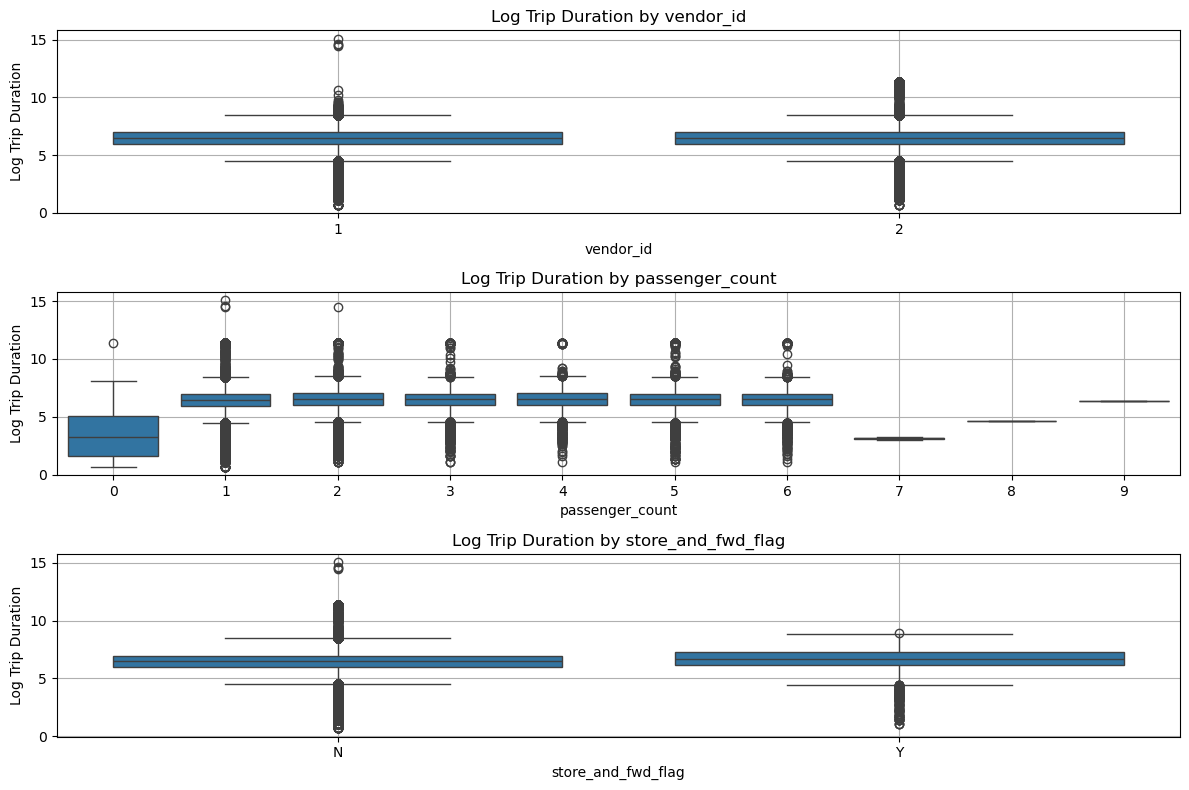

In [613]:
features = ['vendor_id', 'passenger_count', 'store_and_fwd_flag']

plt.figure(figsize=(12, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(3, 1, i)
    sns.boxplot(x=train_data[feature], y=train_data['log_trip_duration'])
    plt.title(f'Log Trip Duration by {feature}')
    plt.xlabel(feature)
    plt.grid()
    plt.ylabel('Log Trip Duration')

plt.tight_layout()
plt.show()

Переведите признаки `vendor_id` и `store_and_fwd_flag` в значения $\{0;1\}$

In [614]:
train_data['store_and_fwd_flag'] = train_data['store_and_fwd_flag'].map({'N': 0, 'Y': 1})
train_data['vendor_id'] = train_data['vendor_id'].map({1: 0, 2: 1})
train_data.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,log_trip_duration,...,haversine,log_haversine,is_traffic,is_free,airport_1_pick,airport_1_drop,airport_2_pick,airport_2_drop,dropoff_cell,pickup_cell
1011257,id2209155,1,2016-05-03 09:03:08,2,-73.979813,40.752529,-73.982681,40.763680,0,6.739337,...,1.263187,0.816774,True,False,False,False,False,False,10,10
178550,id0586605,0,2016-01-01 16:40:51,1,-73.977623,40.746296,-73.968414,40.788933,0,6.909753,...,4.804012,1.758549,True,False,False,False,False,False,15,6
551460,id0467144,0,2016-04-24 13:57:03,1,-73.950699,40.779404,-73.863129,40.768608,0,6.955593,...,7.471088,2.136659,False,False,False,False,False,False,-1,16
1434271,id0989010,1,2016-01-10 17:03:47,1,-73.984558,40.721802,-73.976753,40.752213,0,6.665684,...,3.444869,1.491750,False,False,False,False,False,False,10,2
1173610,id0580742,0,2016-02-25 17:37:36,1,-73.967720,40.768742,-73.977173,40.789875,0,6.597146,...,2.481063,1.247338,True,False,False,False,False,False,14,11


In [615]:
test_data['store_and_fwd_flag'] = test_data['store_and_fwd_flag'].map({'N': 0, 'Y': 1})
test_data['vendor_id'] = test_data['vendor_id'].map({1: 0, 2: 1})

**Вопрос**: Основываясь на графиках выше, как вы думаете, будут ли эти признаки сильными?

**Ответ**: Нет, так как на графике почти у всех одинаковые значения. Модель улучшится, но не сильно.

**Задание 12 (0.25 баллов)**. Проверьте свои предположения, обучив модель в том числе и на этих трех признаках. Обучайте `Ridge`-регрессию со стандартными параметрами. Категориальные признаки закодируйте one-hot-кодированием, а численные отмасштабируйте.

In [617]:
feature = [
    'month', 'hour', 'day_week', 'is_special_day', 'log_haversine', 
    'is_traffic', 'is_free', 'airport_1_pick', 'airport_2_pick',
    'airport_2_drop', 'airport_1_drop', 'dropoff_cell', 'pickup_cell',
    'vendor_id', 'store_and_fwd_flag', 'passenger_count'
]

X_train = train_data[feature]
y_train = train_data['log_trip_duration']

y_test = test_data['log_trip_duration']
X_test = test_data[feature]

categorical_features = ['is_special_day', 'airport_1_pick', 'airport_2_pick', 'airport_2_drop', 'airport_1_drop',
                       'is_traffic', 'is_free', 'vendor_id', 'store_and_fwd_flag']
numerical_features = ['month', 'hour', 'day_week', 'log_haversine', 'dropoff_cell', 'pickup_cell', 'passenger_count']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print("RMSLE:", rmsle(y_test, y_pred))
print("RMSLE_best:", rmsle_best_const)

RMSLE: 0.49606794435255447
RMSLE_best: 0.7957592365411509


Если признаки не дали какого-то ощутимого улучшения метрики, их можно выбросить из данных.

## Часть 4. Улучшаем модель (3 балла)

**Задание 13 (1 балл)**. В наших данных есть нетипичные объекты (выбросы, или outliers): с аномально маленьким времени поездки, с очень большим пройденным расстоянием или очень большими остатками регрессии. В этом задании предлагается исключить такие объекты из обучающей выборки. Для этого нарисуйте гистограммы распределения упомянутых выше величин, выберите объекты, которые можно назвать выбросами, и очистите __обучающую выборку__ от них.

Отметим, что хотя эти объекты и выглядят как выбросы, в тестовой выборке тоже скорее всего будут объекты с такими же странными значениями целевой переменной и/или признаков. Поэтому, возможно, чистка обучающей выборки приведёт к ухудшению качества на тесте. Тем не менее, всё равно лучше удалять выбросы из обучения, чтобы модель получалась более разумной и интерпретируемой.

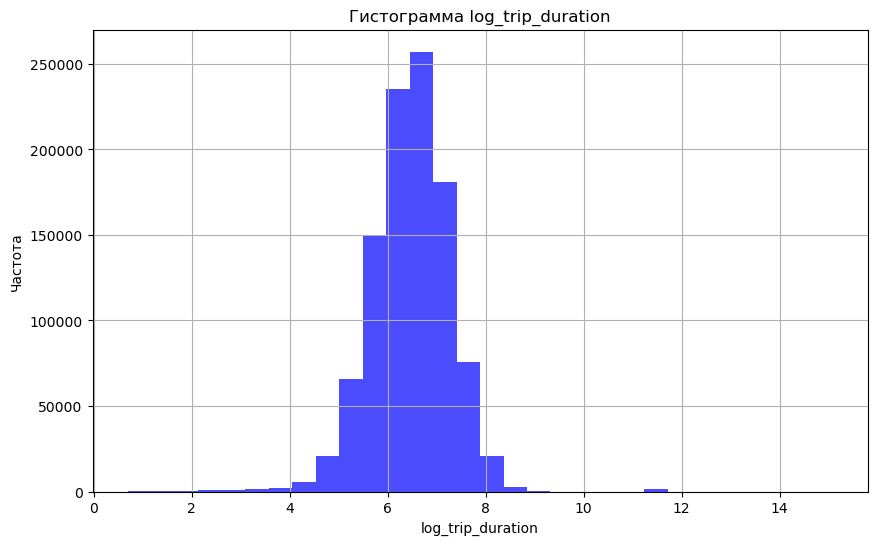

In [618]:
plt.figure(figsize=(10, 6))
plt.grid()
plt.hist(train_data['log_trip_duration'], bins=30, color='blue', alpha=0.7)
plt.title('Гистограмма log_trip_duration')
plt.xlabel('log_trip_duration')
plt.ylabel('Частота')
plt.show()

4 <= log_trip_duration <= 10

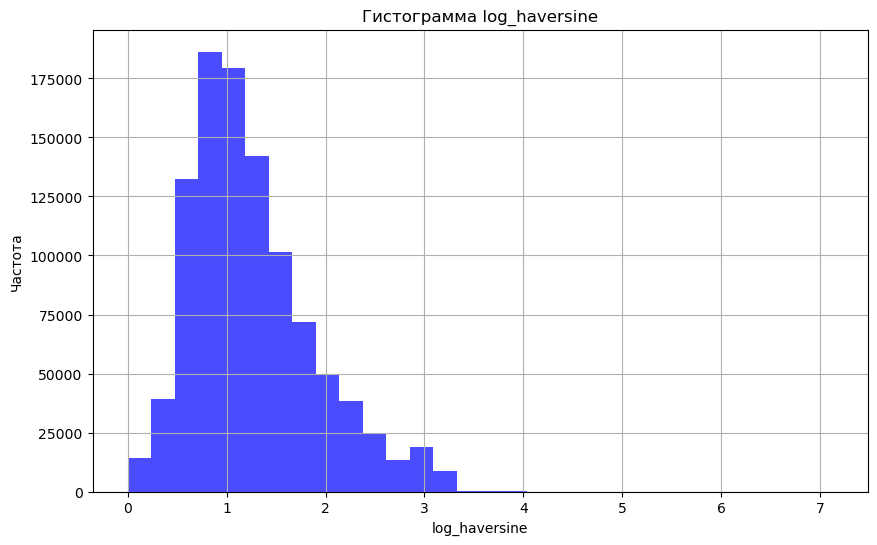

In [619]:
plt.figure(figsize=(10, 6))
plt.grid()
plt.hist(train_data['log_haversine'], bins=30, color='blue', alpha=0.7)
plt.title('Гистограмма log_haversine')
plt.xlabel('log_haversine')
plt.ylabel('Частота')
plt.show()

log_gaversine <= 3.3

In [620]:
train_data = train_data[
    (4 <= train_data['log_trip_duration']) &
    (train_data['log_trip_duration'] <= 10) &
    (train_data['log_haversine'] <= 3.3)
]

Сейчас у нас очень много категориальных признаков. В категориальных признаках могут содержаться редкие категории, обычно это плохо: модель сильно переобучается на таких примерах. Для каждого категориального признака объедините действительно редкие категории в одну, если такие имеются (т.е. если категории действительно редкие).

In [623]:
train_data['airport'] = False
train_data.loc[
    (train_data['airport_1_drop'] == True) |
    (train_data['airport_2_drop'] == True) |
    (train_data['airport_1_pick'] == True) |
    (train_data['airport_2_pick'] == True),
    'airport'
] = True


test_data['airport'] = False
test_data.loc[
    (test_data['airport_1_drop'] == True) |
    (test_data['airport_2_drop'] == True) |
    (test_data['airport_1_pick'] == True) |
    (test_data['airport_2_pick'] == True),
    'airport'
] = True

In [626]:
train_data.drop(columns=['airport_1_drop', 'airport_2_drop', 'airport_1_pick', 'airport_2_pick'], inplace=True)
test_data.drop(columns=['airport_1_drop', 'airport_2_drop', 'airport_1_pick', 'airport_2_pick'], inplace=True)

Обучите модель на очищенных данных и посчитайте качество на тестовой выборке.

In [627]:
feature = [
    'month', 'hour', 'day_week', 'is_special_day', 'log_haversine', 
    'is_traffic', 'is_free', 'airport', 'dropoff_cell', 'pickup_cell',
    'vendor_id', 'store_and_fwd_flag', 'passenger_count'
]

X_train = train_data[feature]
y_train = train_data['log_trip_duration']

y_test = test_data['log_trip_duration']
X_test = test_data[feature]

categorical_features = ['is_special_day', 'airport',
                       'is_traffic', 'is_free', 'vendor_id', 'store_and_fwd_flag']
numerical_features = ['month', 'hour', 'day_week', 'log_haversine', 'dropoff_cell', 'pickup_cell', 'passenger_count']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print("RMSLE:", rmsle(y_test, y_pred))
print("RMSLE_best:", rmsle_best_const)

RMSLE: 0.49854286614497056
RMSLE_best: 0.7957592365411509


**Задание 14 (1 балл)**. После OneHot-кодирования количество признаков в нашем датасете сильно возрастает. Посчитайте колиество признаков до и после кодирования категориальных признаков.

In [628]:
feature = [
    'month', 'hour', 'day_week', 'is_special_day', 'log_haversine', 
    'is_traffic', 'is_free', 'airport', 'dropoff_cell', 'pickup_cell',
    'vendor_id', 'store_and_fwd_flag', 'passenger_count'
]

num_features_before = len(feature)

categorical_features = ['is_special_day', 'airport',
                       'is_traffic', 'is_free', 'vendor_id', 'store_and_fwd_flag']
numerical_features = ['month', 'hour', 'day_week', 'log_haversine', 'dropoff_cell', 'pickup_cell', 'passenger_count']

unique_counts = {}
for col in categorical_features:
    unique_counts[col] = train_data[col].nunique()

num_features_after = num_features_before - len(categorical_features) + sum(unique_counts.values())

print("Before:", num_features_before)
print("After:", num_features_after)

Before: 13
After: 19


Попробуйте обучить не `Ridge`-, а `Lasso`-регрессию. Какой метод лучше?

In [629]:
from sklearn.linear_model import Lasso

feature = [
    'month', 'hour', 'day_week', 'is_special_day', 'log_haversine', 
    'is_traffic', 'is_free', 'airport', 'dropoff_cell', 'pickup_cell',
    'vendor_id', 'store_and_fwd_flag', 'passenger_count'
]

X_train = train_data[feature]
y_train = train_data['log_trip_duration']

y_test = test_data['log_trip_duration']
X_test = test_data[feature]

categorical_features = ['is_special_day', 'airport',
                       'is_traffic', 'is_free', 'vendor_id', 'store_and_fwd_flag']
numerical_features = ['month', 'hour', 'day_week', 'log_haversine', 'dropoff_cell', 'pickup_cell', 'passenger_count']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso())
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print("RMSLE_Lasso:", rmsle(y_test, y_pred))
print("RMSLE_Ridge:", 0.48998455041817557)
print("RMSLE_best:", rmsle_best_const)

RMSLE_Lasso: 0.7951057771741935
RMSLE_Ridge: 0.48998455041817557
RMSLE_best: 0.7957592365411509


Разбейте _обучающую выборку_ на обучающую и валидационную в отношении 8:2. По валидационной выборке подберите оптимальные значения параметра регуляризации (по логарифмической сетке) для `Ridge` и `Lasso`, на тестовой выборке измерьте качество лучшей полученной модели.

In [630]:
train_data_1, test_data_1 = train_test_split(train_data, test_size=0.2, random_state=42)

In [631]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV

feature = [
    'month', 'hour', 'day_week', 'is_special_day', 'log_haversine', 
    'is_traffic', 'is_free', 'airport', 'dropoff_cell', 'pickup_cell',
    'vendor_id', 'store_and_fwd_flag', 'passenger_count'
]

X_train = train_data_1[feature]
y_train = train_data_1['log_trip_duration']

y_test = test_data_1['log_trip_duration']
X_test = test_data_1[feature]

categorical_features = ['is_special_day', 'airport',
                       'is_traffic', 'is_free', 'vendor_id', 'store_and_fwd_flag']
numerical_features = ['month', 'hour', 'day_week', 'log_haversine', 'dropoff_cell', 'pickup_cell', 'passenger_count']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

param_grid_ridge = {'regressor__alpha': np.logspace(-4, 4, 10)}
param_grid_lasso = {'regressor__alpha': np.logspace(-4, 4, 10)}
rmsle_scorer = make_scorer(rmsle, greater_is_better=False)

#Ridge
pipeline_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

grid_search_ridge = GridSearchCV(pipeline_ridge, param_grid_ridge, cv=5, scoring=rmsle_scorer)
grid_search_ridge.fit(X_train, y_train)

#Lasso
pipeline_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso())
])

grid_search_lasso = GridSearchCV(pipeline_lasso, param_grid_lasso, cv=5, scoring=rmsle_scorer)
grid_search_lasso.fit(X_train, y_train)


y_pred_lasso = grid_search_lasso.predict(X_test)
y_pred_ridge = grid_search_ridge.predict(X_test)

print("RMSLE_ridge:", rmsle(y_test, y_pred_ridge))
print("RMSLE_lasso:", rmsle(y_test, y_pred_lasso))
print("RMSLE_best:", rmsle_best_const)

RMSLE_ridge: 0.4298070638751404
RMSLE_lasso: 0.42981212655888196
RMSLE_best: 0.7957592365411509


In [632]:
X_test = test_data[feature]
y_test = test_data['log_trip_duration']

best_model = grid_search_ridge.best_estimator_
y_pred = best_model.predict(X_test)

print("RMSLE_Ridge:", rmsle(y_test, y_pred))
print("RMSLE_best:", rmsle_best_const)

RMSLE_Ridge: 0.49851635264943267
RMSLE_best: 0.7957592365411509


Сохраните наилучшее значение, как бенчмарк на будущее

In [647]:
best_rmsle = 0.49851635264943267

Для каждого перебранного `alpha` для Lasso посчитайте количество нулевых весов в модели и нарисуйте график зависимости его от `alpha`. Как сильно придётся потерять в качестве, если мы хотим с помощью Lasso избавиться хотя бы от половины признаков?

In [634]:
feature = [
    'month', 'hour', 'day_week', 'is_special_day', 'log_haversine', 
    'is_traffic', 'is_free', 'airport', 'dropoff_cell', 'pickup_cell',
    'vendor_id', 'store_and_fwd_flag', 'passenger_count'
]

X_train = train_data[feature]
y_train = train_data['log_trip_duration']
X_test = test_data[feature]
y_test = test_data['log_trip_duration']

categorical_features = ['is_special_day', 'airport', 'is_traffic', 'is_free', 'vendor_id', 'store_and_fwd_flag']
numerical_features = ['month', 'hour', 'day_week', 'log_haversine', 'dropoff_cell', 'pickup_cell', 'passenger_count']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso())
])

alphas = np.logspace(-4, 4, 25)
zero_weights_counts = []
rmsle_count = []

for alpha in alphas:
    pipeline.set_params(regressor=Lasso(alpha=alpha))
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    rmsle_count.append(rmsle(y_pred, y_test))
    
    lasso_model = pipeline.named_steps['regressor']
    zero_weights_counts.append(np.sum(lasso_model.coef_ == 0))

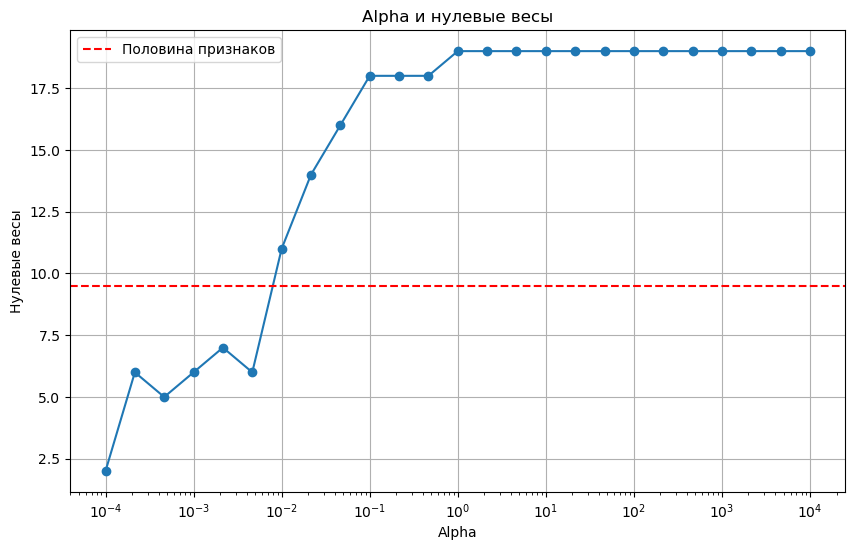

In [635]:
plt.figure(figsize=(10, 6))
plt.plot(alphas, zero_weights_counts, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Нулевые весы')
plt.title('Alpha и нулевые весы')
plt.grid()

plt.axhline(y=19/2, color='r', linestyle='--', label='Половина признаков')

plt.legend()
plt.show()

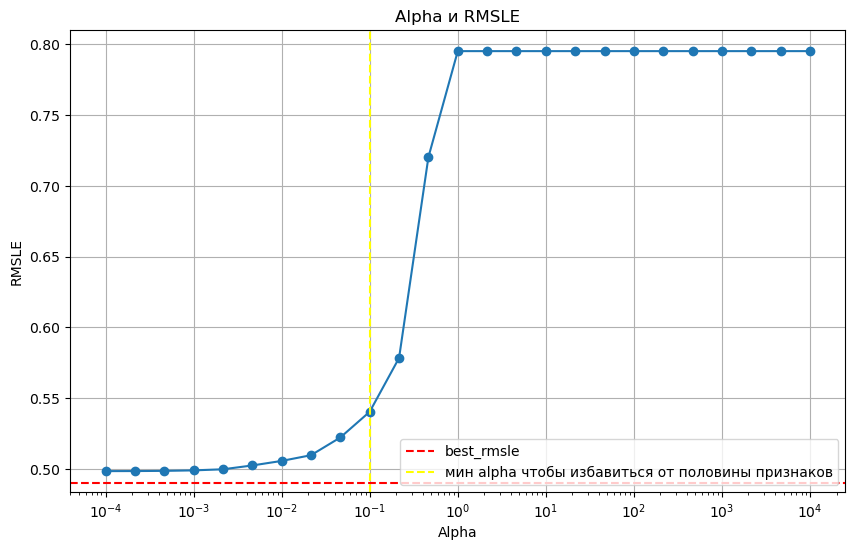

In [636]:
plt.figure(figsize=(10, 6))
plt.plot(alphas, rmsle_count, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('RMSLE')
plt.title('Alpha и RMSLE')
plt.grid()

plt.axhline(y=best_rmsle, color='r', linestyle='--', label='best_rmsle')
plt.axvline(x=0.1, color='yellow', linestyle='--', label='мин alpha чтобы избавиться от половины признаков')

plt.legend()
plt.show()

Если хотим избавлять от хотя бы половины признаков **(когда alpha >= 0.1)**, то мы сильно потеряем оценку моделя. 

<img src="https://www.dropbox.com/s/wp4jj0599np17lh/map_direction.png?raw=1" width="20%" align="right" style="margin-left: 20px">

**Задание 15 (1 балл)**. Часто бывает полезным использовать взаимодействия признаков (feature interactions), то есть строить новые признаки на основе уже существующих. Выше мы разбили карту Манхэттена на ячейки и придумали признаки "из какой ячейки началась поездка" и "в какой ячейке закончилась поездка".

Давайте попробуем сделать следующее: посчитаем, сколько раз встречается каждая возможная пара этих признаков в нашем датасете и выберем 100 самых частых пар. Закодируем поездки с этими частыми парами как категориальный признак, остальным объектам припишем -1. Получается, что мы закодировали, откуда и куда должно было ехать такси.

**Вопрос**: Почему такой признак потенциально полезный? Почему линейная модель не может самостоятельно "вытащить" эту информацию, ведь у нее в распоряжении есть признаки "из какой ячейки началась поездка" и "в какой ячейке закончилась поездка"?

**Ответ**: Признак полезен, так как мы учитываем связь между двумя признаками(часто встречается какая то комюинация из одной клетки в другой) и еще можем уменьшить количество признаков. Не может самостоятельно вытащить так как модель не может сам найти связь между этими двумя признаками, он просто сичтает что это какие то несвязанные признаки


In [687]:
import math

m = folium.Map(location=[40.7831, -73.9712], zoom_start=13)

start_lat, start_lng = 40.7, -74.0
angle_degrees = 55
angle_radians = math.radians(angle_degrees)

angle_degrees1 = -20
angle_radians1 = math.radians(angle_degrees1)

length = 0.15

end_lat = start_lat + length * math.sin(angle_radians)
end_lng = start_lng + length * math.cos(angle_radians)

end_lat1 = start_lat + length * math.sin(angle_radians1)
end_lng1 = start_lng + length * math.cos(angle_radians1)

folium.PolyLine(locations=[[start_lat, start_lng], [end_lat, end_lng]], color='blue', weight=3).add_to(m)
folium.PolyLine(locations=[[start_lat, start_lng], [end_lat1, end_lng1]], color='blue', weight=3).add_to(m)

m

In [637]:
#train_data = train_data.reset_index()

train_data['pick_to_drop'] = train_data['pickup_cell'].astype(str) + '_' + train_data['dropoff_cell'].astype(str)
pair_count = train_data['pick_to_drop'].value_counts()
top_100_pairs = pair_count.nlargest(100).index
train_data['cell_pair_encoded'] = train_data['pick_to_drop'].apply(lambda x: x if x in top_100_pairs else '-1')
train_data.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,log_trip_duration,...,is_special_day,haversine,log_haversine,is_traffic,is_free,dropoff_cell,pickup_cell,airport,pick_to_drop,cell_pair_encoded
1011257,id2209155,1,2016-05-03 09:03:08,2,-73.979813,40.752529,-73.982681,40.763680,0,6.739337,...,False,1.263187,0.816774,True,False,10,10,False,10_10,10_10
178550,id0586605,0,2016-01-01 16:40:51,1,-73.977623,40.746296,-73.968414,40.788933,0,6.909753,...,False,4.804012,1.758549,True,False,15,6,False,6_15,6_15
551460,id0467144,0,2016-04-24 13:57:03,1,-73.950699,40.779404,-73.863129,40.768608,0,6.955593,...,False,7.471088,2.136659,False,False,-1,16,False,16_-1,16_-1
1434271,id0989010,1,2016-01-10 17:03:47,1,-73.984558,40.721802,-73.976753,40.752213,0,6.665684,...,False,3.444869,1.491750,False,False,10,2,False,2_10,2_10
1173610,id0580742,0,2016-02-25 17:37:36,1,-73.967720,40.768742,-73.977173,40.789875,0,6.597146,...,False,2.481063,1.247338,True,False,14,11,False,11_14,11_14


In [638]:
train_data.drop(columns=['pick_to_drop'], inplace=True)
train_data.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,log_trip_duration,...,day_year,is_special_day,haversine,log_haversine,is_traffic,is_free,dropoff_cell,pickup_cell,airport,cell_pair_encoded
1011257,id2209155,1,2016-05-03 09:03:08,2,-73.979813,40.752529,-73.982681,40.763680,0,6.739337,...,124,False,1.263187,0.816774,True,False,10,10,False,10_10
178550,id0586605,0,2016-01-01 16:40:51,1,-73.977623,40.746296,-73.968414,40.788933,0,6.909753,...,1,False,4.804012,1.758549,True,False,15,6,False,6_15
551460,id0467144,0,2016-04-24 13:57:03,1,-73.950699,40.779404,-73.863129,40.768608,0,6.955593,...,115,False,7.471088,2.136659,False,False,-1,16,False,16_-1
1434271,id0989010,1,2016-01-10 17:03:47,1,-73.984558,40.721802,-73.976753,40.752213,0,6.665684,...,10,False,3.444869,1.491750,False,False,10,2,False,2_10
1173610,id0580742,0,2016-02-25 17:37:36,1,-73.967720,40.768742,-73.977173,40.789875,0,6.597146,...,56,False,2.481063,1.247338,True,False,14,11,False,11_14


In [639]:
test_data['pick_to_drop'] = test_data['pickup_cell'].astype(str) + '_' + test_data['dropoff_cell'].astype(str)
pair_count_test = test_data['pick_to_drop'].value_counts()
top_100_pairs_test = pair_count_test.nlargest(100).index
test_data['cell_pair_encoded'] = test_data['pick_to_drop'].apply(lambda x: x if x in top_100_pairs_test else '-1')
test_data.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,log_trip_duration,...,is_special_day,haversine,log_haversine,is_traffic,is_free,dropoff_cell,pickup_cell,airport,pick_to_drop,cell_pair_encoded
67250,id2793718,1,2016-06-08 07:36:19,1,-73.985611,40.735943,-73.980331,40.760468,0,6.947937,...,False,2.763050,1.325230,False,False,10,6,False,6_10,6_10
1397036,id3485529,1,2016-04-03 12:58:11,1,-73.978394,40.764351,-73.991623,40.749859,0,6.719013,...,False,1.959178,1.084912,False,False,6,10,False,10_6,10_6
1021087,id1816614,1,2016-06-05 02:49:13,5,-73.989059,40.744389,-73.973381,40.748692,0,6.421622,...,False,1.404772,0.877455,False,False,7,6,False,6_7,6_7
951424,id1050851,1,2016-05-05 17:18:27,2,-73.990326,40.731136,-73.991264,40.748917,0,6.766192,...,False,1.978660,1.091473,True,False,6,6,False,6_6,6_6
707882,id0140657,0,2016-05-12 17:43:38,4,-73.789497,40.646675,-73.987137,40.759232,0,8.510773,...,False,20.837745,3.083640,True,False,10,-1,True,-1_10,-1_10


In [640]:
test_data.drop(columns=['pick_to_drop'], inplace=True)
test_data.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,log_trip_duration,...,day_year,is_special_day,haversine,log_haversine,is_traffic,is_free,dropoff_cell,pickup_cell,airport,cell_pair_encoded
67250,id2793718,1,2016-06-08 07:36:19,1,-73.985611,40.735943,-73.980331,40.760468,0,6.947937,...,160,False,2.763050,1.325230,False,False,10,6,False,6_10
1397036,id3485529,1,2016-04-03 12:58:11,1,-73.978394,40.764351,-73.991623,40.749859,0,6.719013,...,94,False,1.959178,1.084912,False,False,6,10,False,10_6
1021087,id1816614,1,2016-06-05 02:49:13,5,-73.989059,40.744389,-73.973381,40.748692,0,6.421622,...,157,False,1.404772,0.877455,False,False,7,6,False,6_7
951424,id1050851,1,2016-05-05 17:18:27,2,-73.990326,40.731136,-73.991264,40.748917,0,6.766192,...,126,False,1.978660,1.091473,True,False,6,6,False,6_6
707882,id0140657,0,2016-05-12 17:43:38,4,-73.789497,40.646675,-73.987137,40.759232,0,8.510773,...,133,False,20.837745,3.083640,True,False,10,-1,True,-1_10


Заново обучите модель (`Ridge`, если она дала более высокое качество в предыдущих экспериментах, и `Lasso` иначе) на новых даннных и посчитайте качество на тестовой выборке

In [641]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV

feature = [
    'month', 'hour', 'day_week', 'is_special_day', 'log_haversine', 
    'is_traffic', 'is_free', 'airport', 'cell_pair_encoded',
    'vendor_id', 'store_and_fwd_flag', 'passenger_count'
]

X_train = train_data[feature]
y_train = train_data['log_trip_duration']

y_test = test_data['log_trip_duration']
X_test = test_data[feature]

categorical_features = ['is_special_day', 'airport', 'cell_pair_encoded',
                       'is_traffic', 'is_free', 'vendor_id', 'store_and_fwd_flag']
numerical_features = ['month', 'hour', 'day_week', 'log_haversine', 'passenger_count']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

param_grid_ridge = {'regressor__alpha': np.logspace(-4, 4, 10)}
rmsle_scorer = make_scorer(rmsle, greater_is_better=False)

#Ridge
pipeline_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

grid_search_ridge = GridSearchCV(pipeline_ridge, param_grid_ridge, cv=5, scoring=rmsle_scorer)
grid_search_ridge.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['is_special_day',
                                                                          'airport',
                                                                          'cell_pair_encoded',
                                                                          'is_traffic',
                                                                          'is_free',
                                                                          'vendor_id',
                                                                          'store_and_fwd_flag']),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         ['month',
                                                                          'hour',
                                                                          'day_week',
                                                                          'log_haversine',
                                                                          'passenger_count'])])),
                                       ('regressor', Ridge())]),
             param_grid={'regressor__alpha': array([1.00000000e-04, 7.74263683e-04, 5.99484250e-03, 4.64158883e-02,
       3.59381366e-01, 2.78255940e+00, 2.15443469e+01, 1.66810054e+02,
       1.29154967e+03, 1.00000000e+04])},
             scoring=make_scorer(rmsle, greater_is_better=False, response_method='predict'))

In [651]:
best_alpha = grid_search_ridge.best_params_['regressor__alpha']
print(best_alpha)

2.782559402207126


In [642]:
best_model = grid_search_ridge.best_estimator_
y_pred = best_model.predict(X_test)

print("RMSLE_Ridge:", rmsle(y_test, y_pred))
print("RMSLE_best:", rmsle_best_const)

RMSLE_Ridge: 0.47606441277680317
RMSLE_best: 0.7957592365411509


In [648]:
print('best_rmsle_before:', best_rmsle)
print('best_rmsle_now:', 0.47606441277680317)

best_rmsle_before: 0.49851635264943267
best_rmsle_now: 0.47606441277680317


**Задание 16 (бонус, 1 балл)**. Где, как не для нашей задачи, считать манхэттенское расстояние?

**Вопрос**: Найдите, что такое манхэттенское расстояние и почему оно так называется. Как оно нам может помочь?

**Ответ**: Манхэттенское расстояние может быть полезным в задачах, где перемещение происходит по сетке, например, в городских условиях, где движение ограничено улицами, представляет собой сумму абсолютных разностей между координатами двух точек.

Введите систему координат на нашей карте так, чтобы оси были параллельны улицам Манхэттена, и добавьте сначала в данные признак "манхэттенское расстояние между пунктом отправления и пунктом назначения", а затем и логарифм этого признака. Посчитайте корреляцию между вашим новыми признаком и таргетом; между `log_haversine` и таргетом. В каком случае корреляция больше?

Нарисуйте карту, где покажете выбранные оси. Чтобы мы могли проверить вашу работу, просьба сделать скрин этой карты и приложить картинку (если мы откроем ваш ноутбук, виджеты отображаться не будут).

In [644]:
train = train_data.copy(deep=True)
test = test_data.copy(deep=True)

In [646]:
train['Manhattan'] = (
    np.abs(train['pickup_latitude'] - train['dropoff_latitude']) + 
    np.abs(train['pickup_longitude'] - train['dropoff_longitude'])
)
train['log_Manhattan'] = np.log1p(train['Manhattan'])

test['Manhattan'] = (
    np.abs(test['pickup_latitude'] - test['dropoff_latitude']) + 
    np.abs(test['pickup_longitude'] - test['dropoff_longitude'])
)
test['log_Manhattan'] = np.log1p(test['Manhattan'])

In [649]:
print("log_Manhattan_corr:", train['log_Manhattan'].corr(train['log_trip_duration']))
print("log_haversine_corr", train['log_haversine'].corr(train['log_trip_duration']))

log_Manhattan_corr: 0.6584642861328776
log_haversine_corr 0.7771981223621346


Заново обучите модель на новых даннных и посчитайте качество на тестовой выборке. Стало ли лучше? Объясните полученный результат.

Стало лучше, Манхэттенское расстояние полезен так как движение ограничено улицами.

In [653]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV

feature = [
    'month', 'hour', 'day_week', 'is_special_day', 'log_haversine', 
    'is_traffic', 'is_free', 'airport', 'cell_pair_encoded',
    'vendor_id', 'store_and_fwd_flag', 'passenger_count', 'log_Manhattan'
]

X_train = train[feature]
y_train = train['log_trip_duration']

y_test = test['log_trip_duration']
X_test = test[feature]

categorical_features = ['is_special_day', 'airport', 'cell_pair_encoded',
                       'is_traffic', 'is_free', 'vendor_id', 'store_and_fwd_flag']
numerical_features = ['month', 'hour', 'day_week', 'log_haversine', 'passenger_count', 'log_Manhattan']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

param_grid_ridge = {'regressor__alpha': np.logspace(-4, 4, 10)}
rmsle_scorer = make_scorer(rmsle, greater_is_better=False)

#Ridge
pipeline_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

grid_search_ridge = GridSearchCV(pipeline_ridge, param_grid_ridge, cv=5, scoring=rmsle_scorer)
grid_search_ridge.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['is_special_day',
                                                                          'airport',
                                                                          'cell_pair_encoded',
                                                                          'is_traffic',
                                                                          'is_free',
                                                                          'vendor_id',
                                                                          'store_and_fwd_flag']),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         ['month',
                                                                          'hour',
                                                                          'day_week',
                                                                          'log_haversine',
                                                                          'passenger_count',
                                                                          'log_Manhattan'])])),
                                       ('regressor', Ridge())]),
             param_grid={'regressor__alpha': array([1.00000000e-04, 7.74263683e-04, 5.99484250e-03, 4.64158883e-02,
       3.59381366e-01, 2.78255940e+00, 2.15443469e+01, 1.66810054e+02,
       1.29154967e+03, 1.00000000e+04])},
             scoring=make_scorer(rmsle, greater_is_better=False, response_method='predict'))

In [655]:
best_model = grid_search_ridge.best_estimator_
y_pred = best_model.predict(X_test)

print("RMSLE_Ridge:", rmsle(y_test, y_pred))

RMSLE_Ridge: 0.46847304114268257


**Задание 17 (бонус, 2 балла)**.

Разумеется, погружаться в feature engineering можно ещё очень долго. Ваша задача - придумать какие-то новые признаки, которые сделают модель ещё лучше!! За улучшение функционала ошибки на каждые 0.005 на тестовой выборке относительно `best_rmsle` будет даваться 0.5 бонусных балла. Всего за этот пункт можно получить до 2 бонусных баллов.

При построении признаков старайтесь не допустить утечки целевой переменной (подробнее про это можно почитать в материалах 1-го семинара) — в противном случае хорошего качества на тестовой выборке достичь не получится.

Какие могут быть идеи для вдохновения:

1. Трансформер, который строит разбиение карты по шестигранной решётке с помощью библиотеки [H3](https://github.com/uber/h3-py) и вычисляет признаки на основе такого разбиения, по аналогии с квадратной сеткой  
> Важно: производительность библиотеки существенно зависит от количества шестиугольников на карте (определяется параметром resolution). Подберите такое разрешение, при котором ваш код будет работать за приемлемое время.    

2. Мы пока что никак не использовали историчность и взаимосвязь в данных, хотя информация о том, что было ранее в эти/похожие дни тоже может пригодиться. Попробуйте поискать соседей и/или построить агрегации, например, при помощи groupby, посчитайте какие-либо статистики в пределах какого-то окна (подберите всё это сами, постарайтесь, чтобы это было что-то разумное), и присоедините к основному датафрейму
> Важно: учтите, что разных вариантов агрегаций и статистик существует очень много. Не стесняйтесь выкидывать фичи, которые вам не нравятся (помните про свойство Lasso), используйте эффективные способы хранения данных ([wink](https://www.kaggle.com/code/demche/polars-memory-usage-optimization)-[wink](https://docs.scipy.org/doc/scipy/reference/sparse.html))

3. В конце концов можно использовать альтернативные способы преобразования данных. Например, использовать другой scaler, другую кодировку категориальных фичей, другие гиперпараметры и пр. Но помните, что на данный момент мы ограничены только `Ridge` и `Lasso`

Вставьте картинку, описывающую ваш опыт выполнения этого ДЗ.